In [ ]:
import tiktoken
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap
import os
from tqdm.notebook import tqdm
import html


In [92]:
enc = tiktoken.get_encoding("gpt2")
vocab_size = enc.n_vocab

In [93]:
d_model = 768
n_heads = 12
d_head = 64 # changeables

vocab_size = enc.n_vocab
batch_size = 32
context_len = 128

lr = 3e-4

epochs = 50_000
eval_iters = 20
device = 'mps'
load_check_point = True
data_dir = os.path.join('../data', "openwebtext")

# Arrays to store data
step_history = []
# We need to store mean and std separately
train_history = {'mean': [], 'std': []}
val_history = {'mean': [], 'std': []}

In [94]:
def get_batch(split):
    # We recreate np.memmap every batch to avoid a memory leak, as per
    # https://stackoverflow.com/questions/45132940/numpy-memmap-memory-usage-want-to-iterate-once/61472122#61472122
    if split == 'train':
        data = np.memmap(os.path.join(data_dir, 'train.bin'), dtype=np.uint16, mode='r')
    else:
        data = np.memmap(os.path.join(data_dir, 'val.bin'), dtype=np.uint16, mode='r')
    ix = torch.randint(len(data) - context_len, (batch_size,))
    x = torch.stack([torch.from_numpy((data[i:i+context_len]).astype(np.int64)) for i in ix])
    y = torch.stack([torch.from_numpy((data[i+1:i+1+context_len]).astype(np.int64)) for i in ix])
    x, y = x.to(device), y.to(device)
    return x, y

In [95]:
class TwoLayerTransformer(nn.Module):
    def __init__(self, vocab_size: int, d_model: int, n_heads: int, d_head: int, context_len: int):
        super().__init__()
        self.vocab_size = vocab_size
        self.d_model = d_model
        self.n_heads = n_heads
        self.d_head = d_head 
        self.context_len = context_len
        self.num_layers = 2  # Defined explicitly

        # Embeddings
        self.W_E = nn.Embedding(self.vocab_size, self.d_model)
        self.W_pos = nn.Embedding(context_len, d_model)

        # We use ModuleList to hold the weights for Layer 0 and Layer 1 separate
        self.W_Q = nn.ModuleList([nn.Linear(self.d_model, self.n_heads * self.d_head, bias=False) for _ in range(self.num_layers)])
        self.W_K = nn.ModuleList([nn.Linear(self.d_model, self.n_heads * self.d_head, bias=False) for _ in range(self.num_layers)])
        self.W_V = nn.ModuleList([nn.Linear(self.d_model, self.n_heads * self.d_head, bias=False) for _ in range(self.num_layers)])
        self.W_O = nn.ModuleList([nn.Linear(self.n_heads * self.d_head, self.d_model, bias=False) for _ in range(self.num_layers)])

        # Unembedding
        self.W_U = nn.Linear(self.d_model, self.vocab_size)

    def forward(self, x: torch.Tensor, return_all: bool = False):
        device = x.device
        B, T = x.shape
        pos = torch.arange(T, device=device)
        
        # 1. Embedding
        x = self.W_E(x) + self.W_pos(pos)
        
        # Storage for visualization if return_all=True
        cache = {
            'scores': [],
            'pattern': [],
            'v': [],
            'z': []
        }

        # 2. Loop over layers (Layer 0 then Layer 1)
        for i in range(self.num_layers):
            residual = x 
            
            # Calculate Q, K, V for this specific layer [i]
            q = self.W_Q[i](x) 
            k = self.W_K[i](x)  
            v = self.W_V[i](x)

            # Reshape for multi-head attention
            q = q.view(B, T, self.n_heads, self.d_head).transpose(1, 2)
            k = k.view(B, T, self.n_heads, self.d_head).transpose(1, 2)
            v = v.view(B, T, self.n_heads, self.d_head).transpose(1, 2)

            # Attention Scores
            scores = torch.matmul(q, k.transpose(-2, -1)) / self.d_head ** 0.5 
            
            # Masking
            mask = torch.triu(torch.ones(T, T, device=device, dtype=torch.bool), diagonal=1)
            scores = scores.masked_fill(mask, float('-inf'))
            
            # Softmax (Attention Pattern)
            pattern = F.softmax(scores, dim=-1)

            # Weighted Sum
            z = torch.matmul(pattern, v) 
            z = z.transpose(1, 2).contiguous().view(B, T, -1)
            
            # Output Projection
            attn_out = self.W_O[i](z)

            # Residual Connection (Crucial for deep networks)
            x = attn_out + residual
            
            # Save cache for this layer
            if return_all:
                cache['scores'].append(scores)
                cache['pattern'].append(pattern)
                cache['v'].append(v)
                cache['z'].append(z)

        # 3. Unembedding
        logits = self.W_U(x)

        if return_all:
            # We return lists containing the data for Layer 0 and Layer 1
            return logits, cache
            
        return logits

In [96]:
model = TwoLayerTransformer(
    vocab_size=vocab_size,
    d_model= d_model,
    n_heads=n_heads,
    d_head=d_head,
    context_len=context_len
)
model.to(device)

optim = optim.AdamW(model.parameters(), lr, betas=(0.9, 0.999))

# Load checkpoint if needed
if load_check_point:
    checkpoint = torch.load('one_layer_transformer.pth', map_location=device)
    model.load_state_dict(checkpoint['model'])
    if 'optimizer' in checkpoint:
        optim.load_state_dict(checkpoint['optimizer'])


In [97]:
@torch.no_grad()
def estimate_loss():
    out = {}
    model.eval()
    for split in ['train', 'val']:
        losses = torch.zeros(eval_iters)
        for k in range(eval_iters):
            X, Y = get_batch(split)
            logits = model(X)
            B, T, C = logits.shape
            loss = F.cross_entropy(logits.view(B*T, C), Y.view(B*T))
            losses[k] = loss.item()
        
        # Calculate Mean and Standard Deviation
        out[split] = {
            'mean': losses.mean().item(),
            'std': losses.std().item()
        }
    model.train()
    return out

In [98]:
pbar = tqdm(range(100), desc="Training Model")

for epoch in pbar:

    if epoch % 20 == 0:
        stats = estimate_loss()
        step_history.append(epoch)
        train_history['mean'].append(stats['train']['mean'])
        train_history['std'].append(stats['train']['std'])
        val_history['mean'].append(stats['val']['mean'])
        val_history['std'].append(stats['val']['std'])
        
        print(f"step {epoch}: val loss {stats['val']['mean']:.4f} +/- {stats['val']['std']:.4f}")

    xb, yb = get_batch('train')

    # Forward pass
    logits = model(xb)
    B, T, C = logits.shape
    loss = F.cross_entropy(logits.view(B*T, C), yb.view(B*T))

    # Backward pass
    optim.zero_grad()
    loss.backward()
    optim.step()
    
    pbar.set_postfix({"loss": f"{loss.item():.4f}"})

Training Model:   0%|          | 0/100 [00:00<?, ?it/s]

step 0: val loss 4.6550 +/- 0.0839
step 20: val loss 4.6507 +/- 0.1155
step 40: val loss 4.6386 +/- 0.0981
step 60: val loss 4.6301 +/- 0.0957
step 80: val loss 4.6186 +/- 0.0985


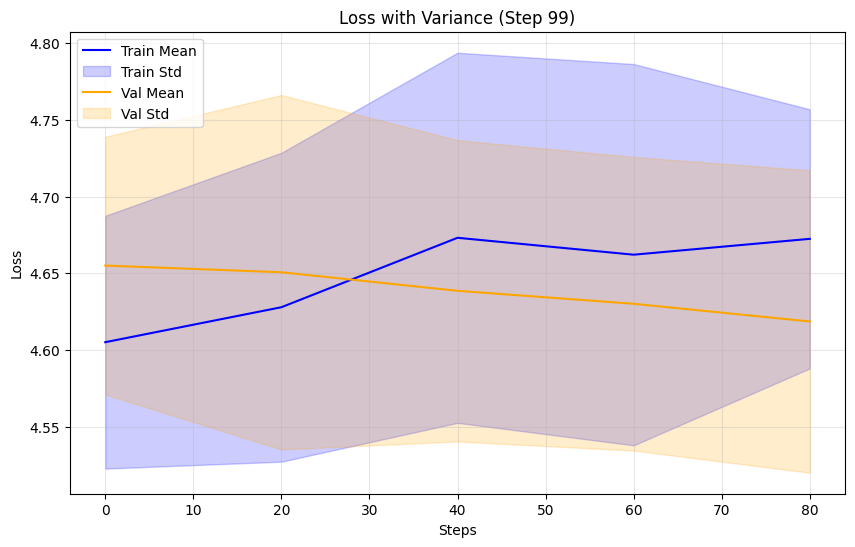

In [99]:
steps = np.array(step_history)
t_mean = np.array(train_history['mean'])
t_std  = np.array(train_history['std'])
v_mean = np.array(val_history['mean'])
v_std  = np.array(val_history['std'])

plt.figure(figsize=(10, 6))

plt.plot(steps, t_mean, label='Train Mean', color='blue')
plt.fill_between(steps, t_mean - t_std, t_mean + t_std, color='blue', alpha=0.2, label='Train Std')

# Plot Validation
plt.plot(steps, v_mean, label='Val Mean', color='orange')
plt.fill_between(steps, v_mean - v_std, v_mean + v_std, color='orange', alpha=0.2, label='Val Std')

plt.title(f'Loss with Variance (Step {epoch})')
plt.xlabel('Steps')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [100]:
checkpoint = {
    'model': model.state_dict(),
    'optimizer': optim.state_dict(),
}
torch.save(checkpoint, 'one_layer_transformer.pth')

In [101]:
from torch.nn.functional import cosine_similarity
embedding_weights = model.W_E.weight

def find_closest_words(word, top_n=50):
    word_id = enc.encode(word)
    word_vector = embedding_weights[word_id]
    
    similarities = cosine_similarity(word_vector.unsqueeze(0), embedding_weights)
    
    top_values, top_indices = similarities.topk(top_n + 1)
    
    print(f"\nWords most similar to '{word}':")
    for i in range(1, top_n + 1): # Start at 1 to skip the word itself
        similar_word_id = top_indices[0][i].item()
        print(similar_word_id)
        similar_word = enc.decode([similar_word_id])
        similarity_score = top_values[0][i].item()
        print(f"   - {similar_word}: {similarity_score:.4f}")

find_closest_words("cat", top_n=5)
find_closest_words("love", top_n=5)


Words most similar to 'cat':
747
   - iss: 0.0458
435
   -  al: 0.0429
58
   - [: 0.0428
446
   - ard: 0.0408
243
   - �: 0.0405

Words most similar to 'love':
58
   - [: 0.0428
446
   - ard: 0.0408
243
   - �: 0.0405
738
   - ident: 0.0395
271
   - is: 0.0379


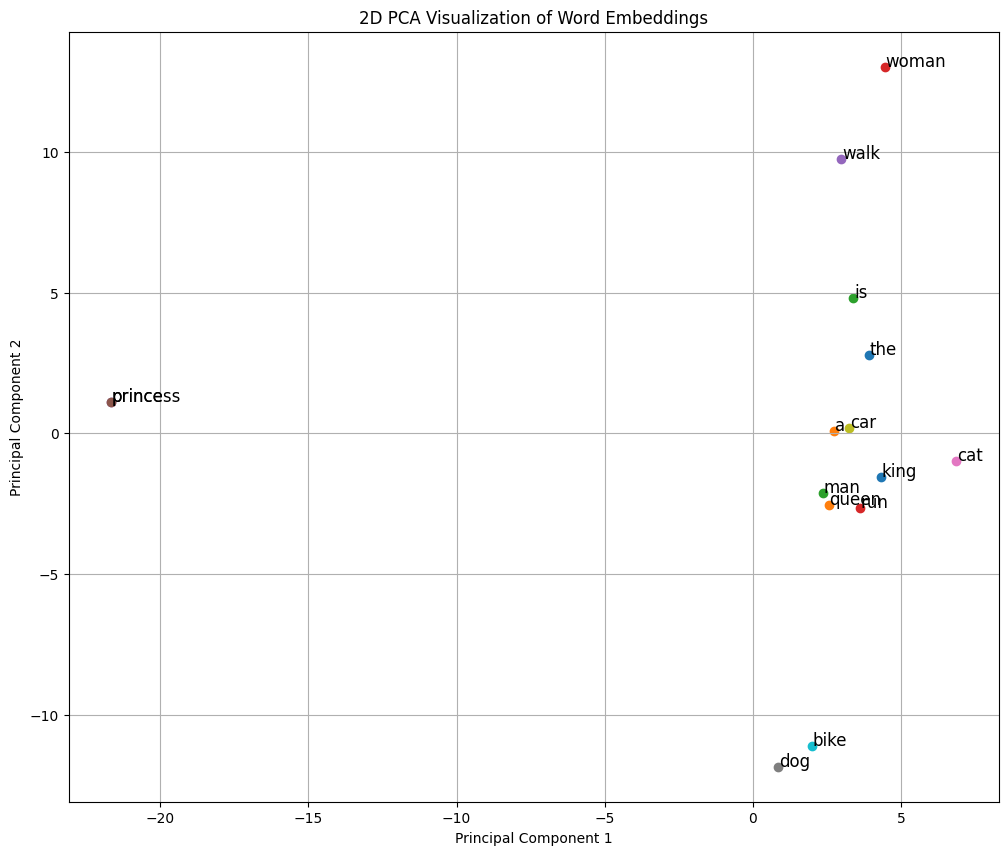

In [102]:
embeddings = model.W_E.weight.detach().cpu().numpy()
vocab_size, d_model = embeddings.shape

all_tokens = [enc.decode([i]) for i in range(vocab_size)]

words_to_track = ["king", "queen", "man", "woman", "prince", "princess", 
                  "cat", "dog", "car", "bike", "the", "a", "is", "run", "walk"]

indices_to_track = [enc.encode(word)[0] for word in words_to_track]

embeddings_subset = embeddings[indices_to_track]

pca = PCA(n_components=2)
embeddings_2d = pca.fit_transform(embeddings_subset)

plt.figure(figsize=(12, 10))

for i, word in enumerate(words_to_track):
    x, y = embeddings_2d[i, 0], embeddings_2d[i, 1]
    plt.scatter(x, y)
    plt.text(x + 0.02, y + 0.02, word, fontsize=12)

plt.title("2D PCA Visualization of Word Embeddings")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid(True)
plt.show()


In [103]:
def sample_from_model(model, start_text, encoder, max_new_tokens, temperature=1.0, top_k=50):
    model.eval()
    model.to(device)

    start_tokens = encoder.encode(start_text)
    idx = torch.tensor(start_tokens, dtype=torch.long, device=device)
    if idx.dim() == 1:
        idx = idx.unsqueeze(0) 

    for _ in range(max_new_tokens):
        logits = model(idx)
        logits = logits[:, -1, :] 
        
        if temperature != 0:
            logits = logits / temperature

        if top_k is not None:
            top_logits, top_idx = torch.topk(logits, top_k, dim=-1)
            logits_filtered = torch.full_like(logits, float('-inf'))
            logits_filtered.scatter_(1, top_idx, top_logits)
            logits = logits_filtered

        probs = F.softmax(logits, dim=-1)
        next_idx = torch.multinomial(probs, num_samples=1)
        
        idx = torch.cat((idx, next_idx), dim=1)
        
    generated_tokens = idx.squeeze(0).cpu().numpy()
    return encoder.decode(generated_tokens)

In [104]:
# """3 + 4 = 7, 2 + 6 = 8, 1 + 3 = 4, 4 + 2 = 6, 2 + 0 = 2, 1 + 2 = 3, 1 + 1 = 2, 4 + 4 = 8, 1 + 3 = 4, 4 + 1 = 5, 7 + 2 = 9, 2 + 3 = 5, 6 + 2 = 8,  4 + 5 = """
start_prompt = """The reality of life is """
generated_text = sample_from_model(
    model=model,
    start_text=start_prompt,
    encoder=enc,
    max_new_tokens=100,
    temperature=0.8,
    top_k=100
)

print("\n--- Generated Text ---")
print(generated_text)


--- Generated Text ---
The reality of life is vernacular, the one is that the one, the others is, as well as the other. In this world, the company is suffering from a small organization that the real cause of the disaster is a mere $20 billion worth of effort and in reality.<|endoftext|>If you guys don't want to think of you guys want to be working together, then you're thinking it will be tough to add to the world to your favorite place.

The move is a team of talented young talent and


In [105]:
def test_prompt(model, start_text, encoder, test_sample, temperature=1):
    model.eval()
    model.to(device)

    start_tokens = encoder.encode(start_text)
    idx = torch.tensor(start_tokens, dtype=torch.long, device=device)
    if idx.dim() == 1:
        idx = idx.unsqueeze(0) 

    logits = model(idx)
    logits = logits[0, -1, :] 
    
    if temperature != 0:
        logits = logits / temperature

    probs = F.softmax(logits, dim=-1)
    p = probs.reshape(-1).cpu()
    v = logits.reshape(-1).cpu()

    sorted_values, original_indices = torch.sort(p, descending=True)
        
    scaled_values = sorted_values * 100
    formatted_values = [f"{val:.3f}" for val in scaled_values]
    decoded_test_token = enc.encode(test_sample)[0]

    print(p[decoded_test_token])
    print("Token | Value (%)")
    print("---------------------")
    for i,(idx, val_str) in enumerate(zip(original_indices, formatted_values)):
        decoded_token = enc.decode([idx.item()])
        if i < 9:
            print(f"Top {i}th token. | Logits: {v[idx].item():.3f},  Probs: {val_str:<3}% | Token: {decoded_token:<20}")
        if idx == decoded_test_token:
            print(f"Top {i}th token. | Logits: {v[idx].item():.3f},  Probs: {val_str:<3}% | Token: {decoded_token:<20}")

    return probs, logits

In [106]:
probs, values = test_prompt(model, """Mr Dursley was privet driver. 
Mr Dursley was the director of a firm.
Mr Dursley was thin and blonde and had nearly twice the usual amount of neck.
Mr Dursley had a small son called Dudley. 
Mr""", enc, ' Dursley')

tensor(0.6918, grad_fn=<SelectBackward0>)
Token | Value (%)
---------------------
Top 0th token. | Logits: 13.209,  Probs: 69.180% | Token:  D                  
Top 0th token. | Logits: 13.209,  Probs: 69.180% | Token:  D                  
Top 1th token. | Logits: 9.744,  Probs: 2.163% | Token:  C                  
Top 2th token. | Logits: 9.669,  Probs: 2.006% | Token:  E                  
Top 3th token. | Logits: 9.651,  Probs: 1.970% | Token:  B                  
Top 4th token. | Logits: 9.394,  Probs: 1.524% | Token: .                   
Top 5th token. | Logits: 9.225,  Probs: 1.287% | Token:  R                  
Top 6th token. | Logits: 9.211,  Probs: 1.269% | Token:  L                  
Top 7th token. | Logits: 8.824,  Probs: 0.862% | Token:  F                  
Top 8th token. | Logits: 8.737,  Probs: 0.790% | Token:  J                  


In [107]:
input_text = """A B C D E A B C D E A B C D E A B C D """

tokens = enc.encode(input_text)
input_tensor = torch.tensor(tokens).unsqueeze(0)
input_tensor= input_tensor.to(device)

model.eval()
model.to(device)
with torch.no_grad():
    logits, cache = model(input_tensor, return_all=True)


In [108]:
def get_weighted_attnetion(cache, layer):
    v_norms = torch.norm(cache['v'][layer], p=2, dim=-1)
    v_norms_expanded = v_norms.unsqueeze(-2)
    weighted_contributions = cache['pattern'][layer] * v_norms_expanded
    return weighted_contributions

layer_1_weighted_contributions = get_weighted_attnetion(cache, 0)
layer_2_weighted_contributions = get_weighted_attnetion(cache, 1)

In [109]:
def plot_all_heads_next_token(attention_pattern, tokens, title='Layer Prediction Breakdown', figsize=(20, 12)):
    """
    Plots a grid of bar charts.
    Each subplot shows what a specific Head is looking at to predict the NEXT token.
    """
    # 1. Prepare Data
    # Get the last query position for ALL heads
    # Shape: [batch, heads, queries, keys] -> [heads, keys]
    if torch.is_tensor(attention_pattern):
        # Taking batch 0, all heads, last query (-1), all keys
        attn_data = attention_pattern[0, :, -1, :].detach().cpu().numpy()
    else:
        attn_data = attention_pattern[0, :, -1, :]

    num_heads = attn_data.shape[0]
    seq_len = attn_data.shape[1]

    # Ensure tokens match sequence length
    if len(tokens) > seq_len:
        tokens = tokens[:seq_len]
    
    # 2. Setup Grid
    rows = int(np.ceil(num_heads / 4))
    cols = min(num_heads, 4)
    
    fig, axes = plt.subplots(rows, cols, figsize=figsize, sharey=True)
    axes = axes.flatten() # Flattens the 2D grid into a 1D list for easy looping
    
    fig.suptitle(title, fontsize=20, y=1.02)
    decodeds = [enc.decode([i]) for i in tokens]

    # 3. Plot Loop
    for i in range(num_heads):
        ax = axes[i]
        scores = attn_data[i]
        
        # Draw Bars
        bars = ax.bar(range(len(scores)), scores, color='#a5b4fc', edgecolor='#4338ca')
        
        # Highlight the Winner (Max Attention)
        max_idx = np.argmax(scores)
        # if scores[max_idx] > 0.01: # Only highlight if there is actually attention
        bars[max_idx].set_color('#f59e0b') # Orange
        bars[max_idx].set_edgecolor('#b45309')
        bars[max_idx].set_linewidth(1.5)
            
            # Annotate the winner value
        ax.text(max_idx, scores[max_idx], f"{scores[max_idx]:.2f}", 
                    ha='center', va='bottom', fontsize=8, fontweight='bold', color='#b45309')

        # Styling
        ax.set_title(f"Head {i}", fontsize=12, fontweight='bold')
        ax.grid(axis='y', alpha=0.3, linestyle='--')
        
        # X-Axis Labels (The Tokens)
        # We rotate them 90 degrees so they fit
        ax.set_xticks(range(len(decodeds)))
        ax.set_xticklabels(decodeds, rotation=90, fontsize=8)
        
        # Only put Y label on the first column to reduce clutter
        if i % cols == 0:
            ax.set_ylabel("Attention / Impact")

    # Hide empty subplots if num_heads isn't a perfect multiple of 4
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

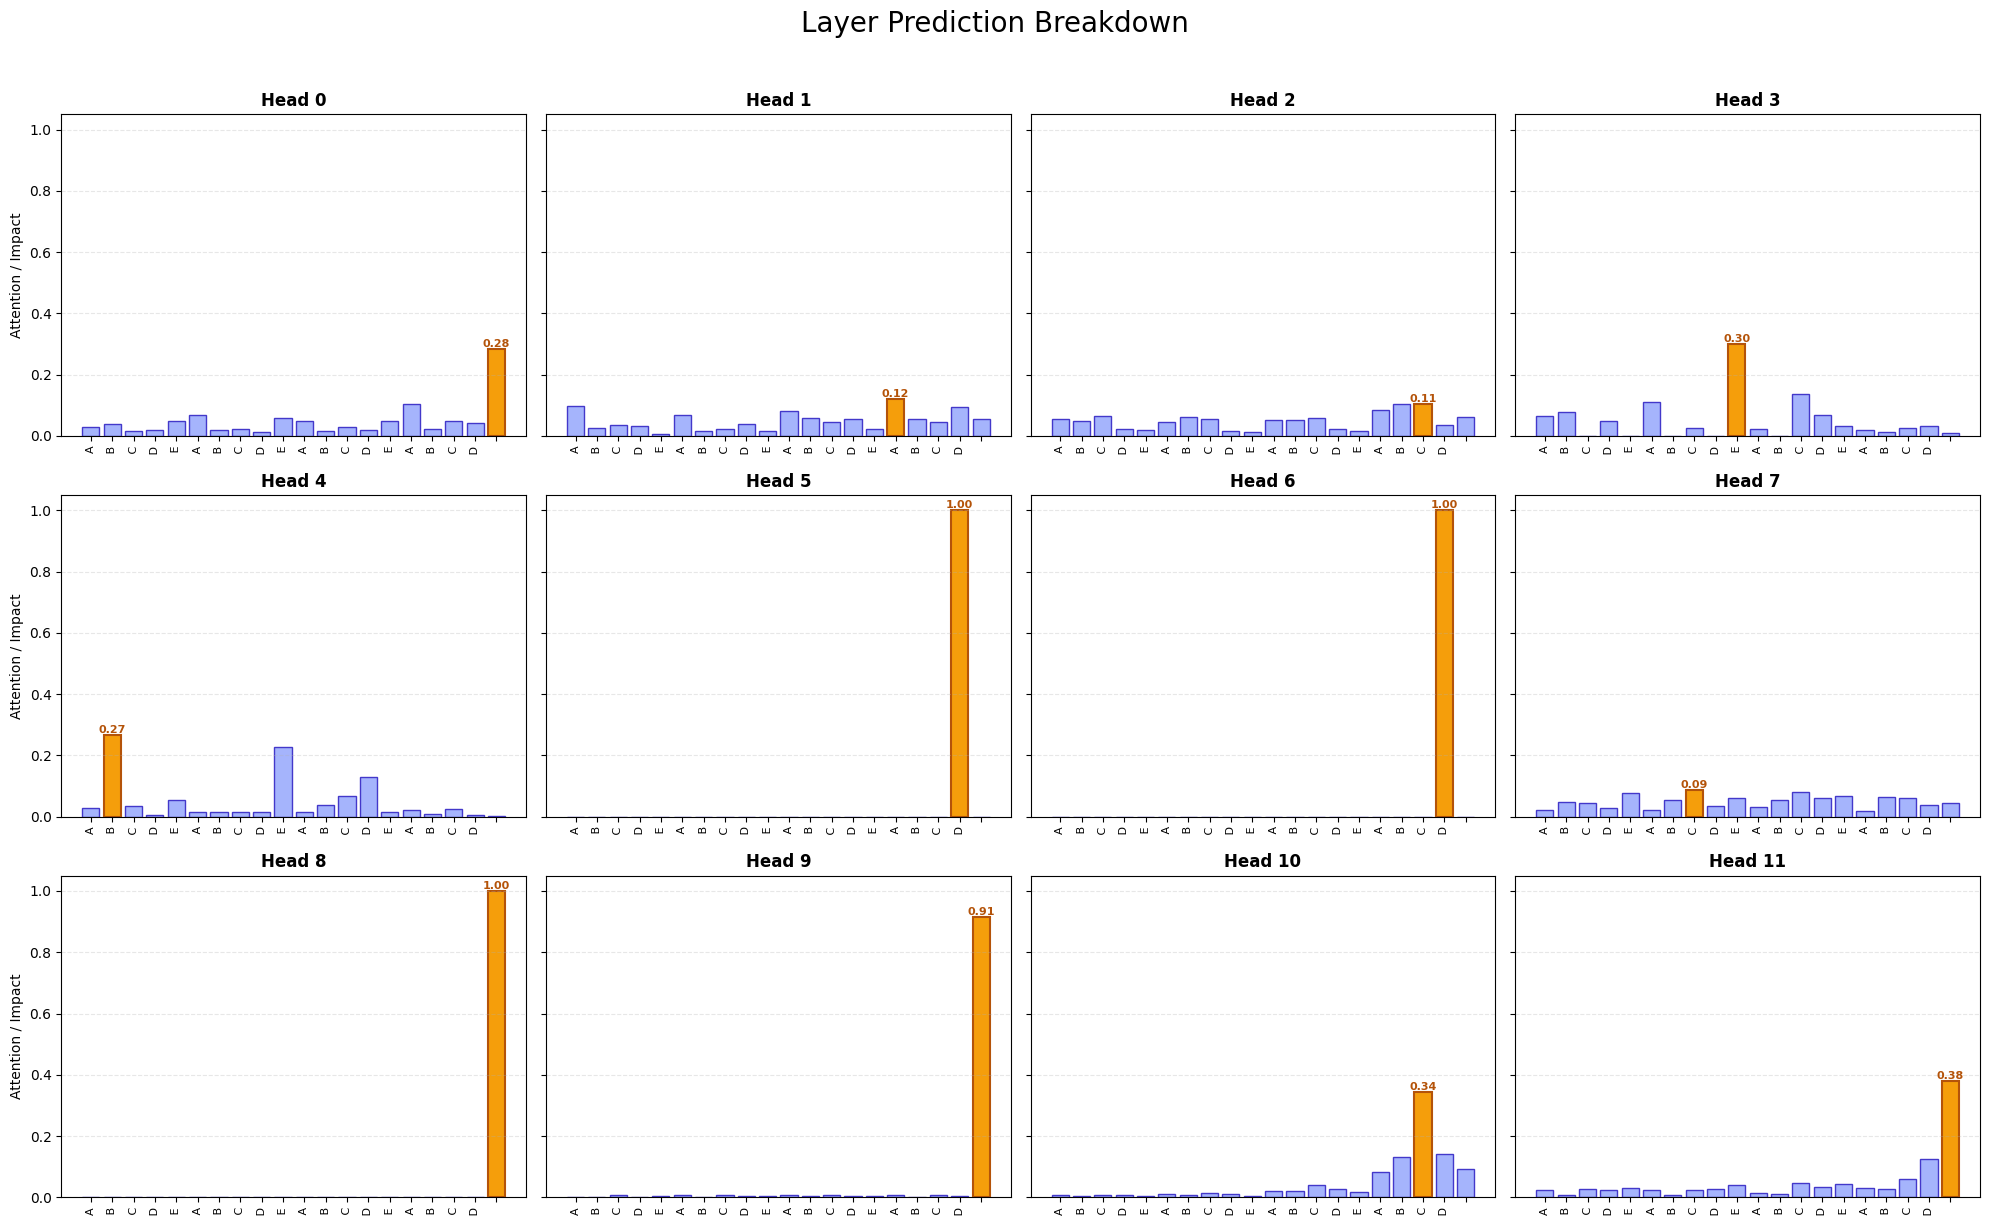

In [110]:
plot_all_heads_next_token(cache['pattern'][0], tokens)

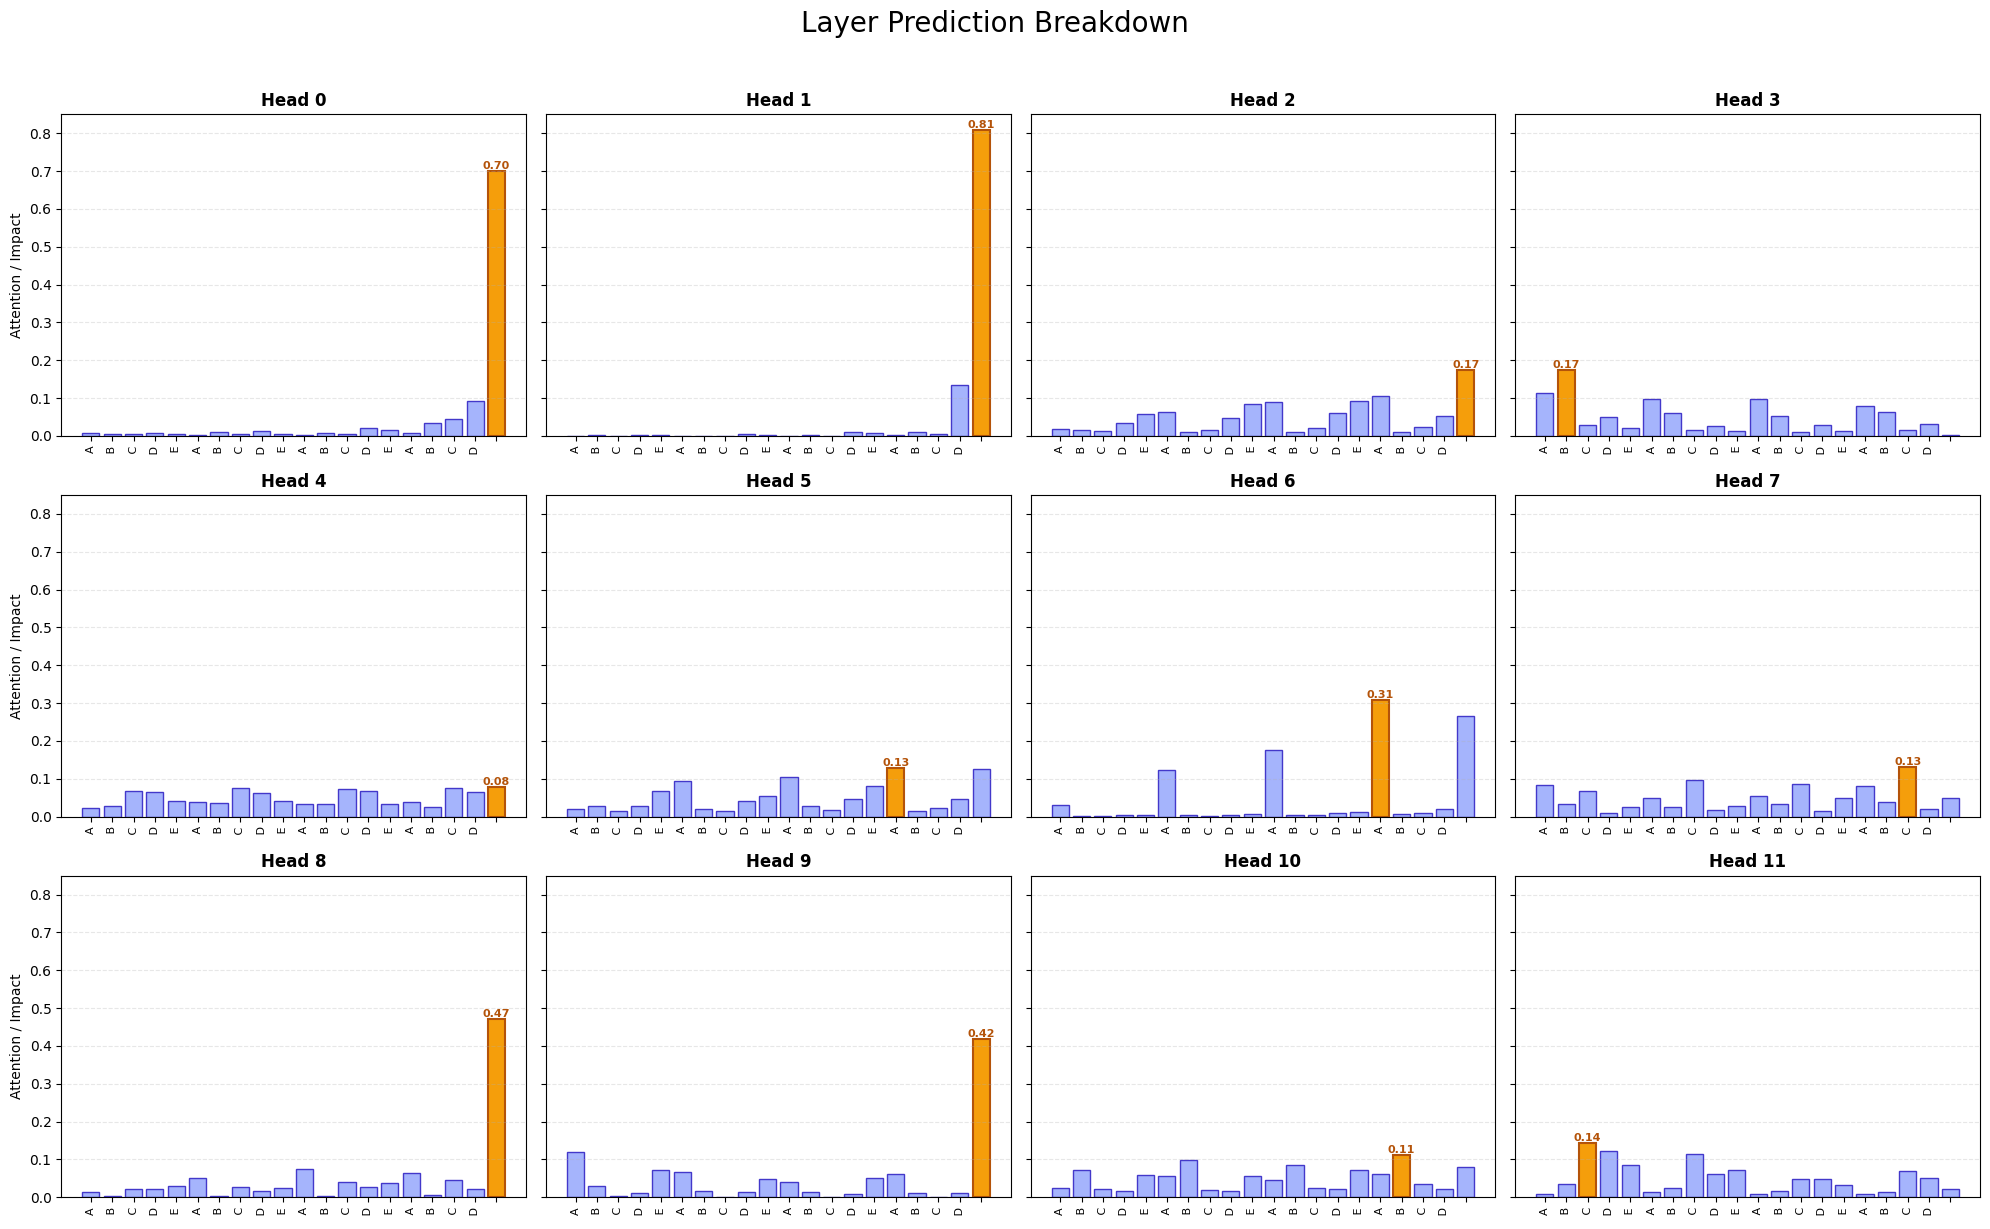

In [111]:
plot_all_heads_next_token(cache['pattern'][1], tokens)

In [112]:
def plot_attention_heads(qk_scores, tokens, title = '' ,figsize=(15, 12)):
    """
    qk_scores: Tensor of shape (batch, num_heads, seq_len, seq_len)
    tokens: List of strings matching the seq_len
    """
    if torch.is_tensor(qk_scores):
        qk_scores_np = qk_scores.detach().cpu().numpy()
    else:
        qk_scores_np = qk_scores
    
    # Validation
    batch, num_heads, seq_len, _ = qk_scores_np.shape
    if len(tokens) != seq_len:
        print(f"Warning: Token list length ({len(tokens)}) does not match sequence length ({seq_len})")
        # Truncate or pad tokens to match to prevent crash
        tokens = tokens[:seq_len] 

    # Calculate grid size (e.g. for 12 heads, do 3x4 or 4x3)
    rows = int(np.ceil(num_heads / 4))
    cols = min(num_heads, 4)
    
    fig, axes = plt.subplots(rows, cols, figsize=figsize)
    # Flatten axes array for easy iteration if it's multidimensional
    if num_heads > 1:
        axes = axes.flatten()
    else:
        axes = [axes]
        
    fig.suptitle(title, fontsize=16)
    
    # Generate distinct colors for each head
    base_colors = plt.cm.tab20(np.linspace(0, 1, num_heads))
    decodeds = [enc.decode([i]) for i in tokens]
    for i in range(num_heads):
        ax = axes[i]
        
        # Create a custom colormap from White -> Head Color
        cmap = LinearSegmentedColormap.from_list(
            f'custom_cmap_{i}', 
            [(1, 1, 1, 0), base_colors[i]], 
            N=256
        )

        
        # Draw Heatmap
        sns.heatmap(
            qk_scores_np[0, i, :, :], 
            cmap=cmap,
            ax=ax,
            cbar=True,
            xticklabels=decodeds, # <--- PUT TOKENS ON X
            yticklabels=decodeds, # <--- PUT TOKENS ON Y
            vmin=0, 
            vmax=np.max(qk_scores_np[0, i, :, :])
        )
        
        ax.set_title(f'Head {i}')
        # Rotate labels so they don't overlap
        ax.set_xticklabels(ax.get_xticklabels(), rotation=90, fontsize=9)
        ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)
        
    plt.tight_layout()
    return fig

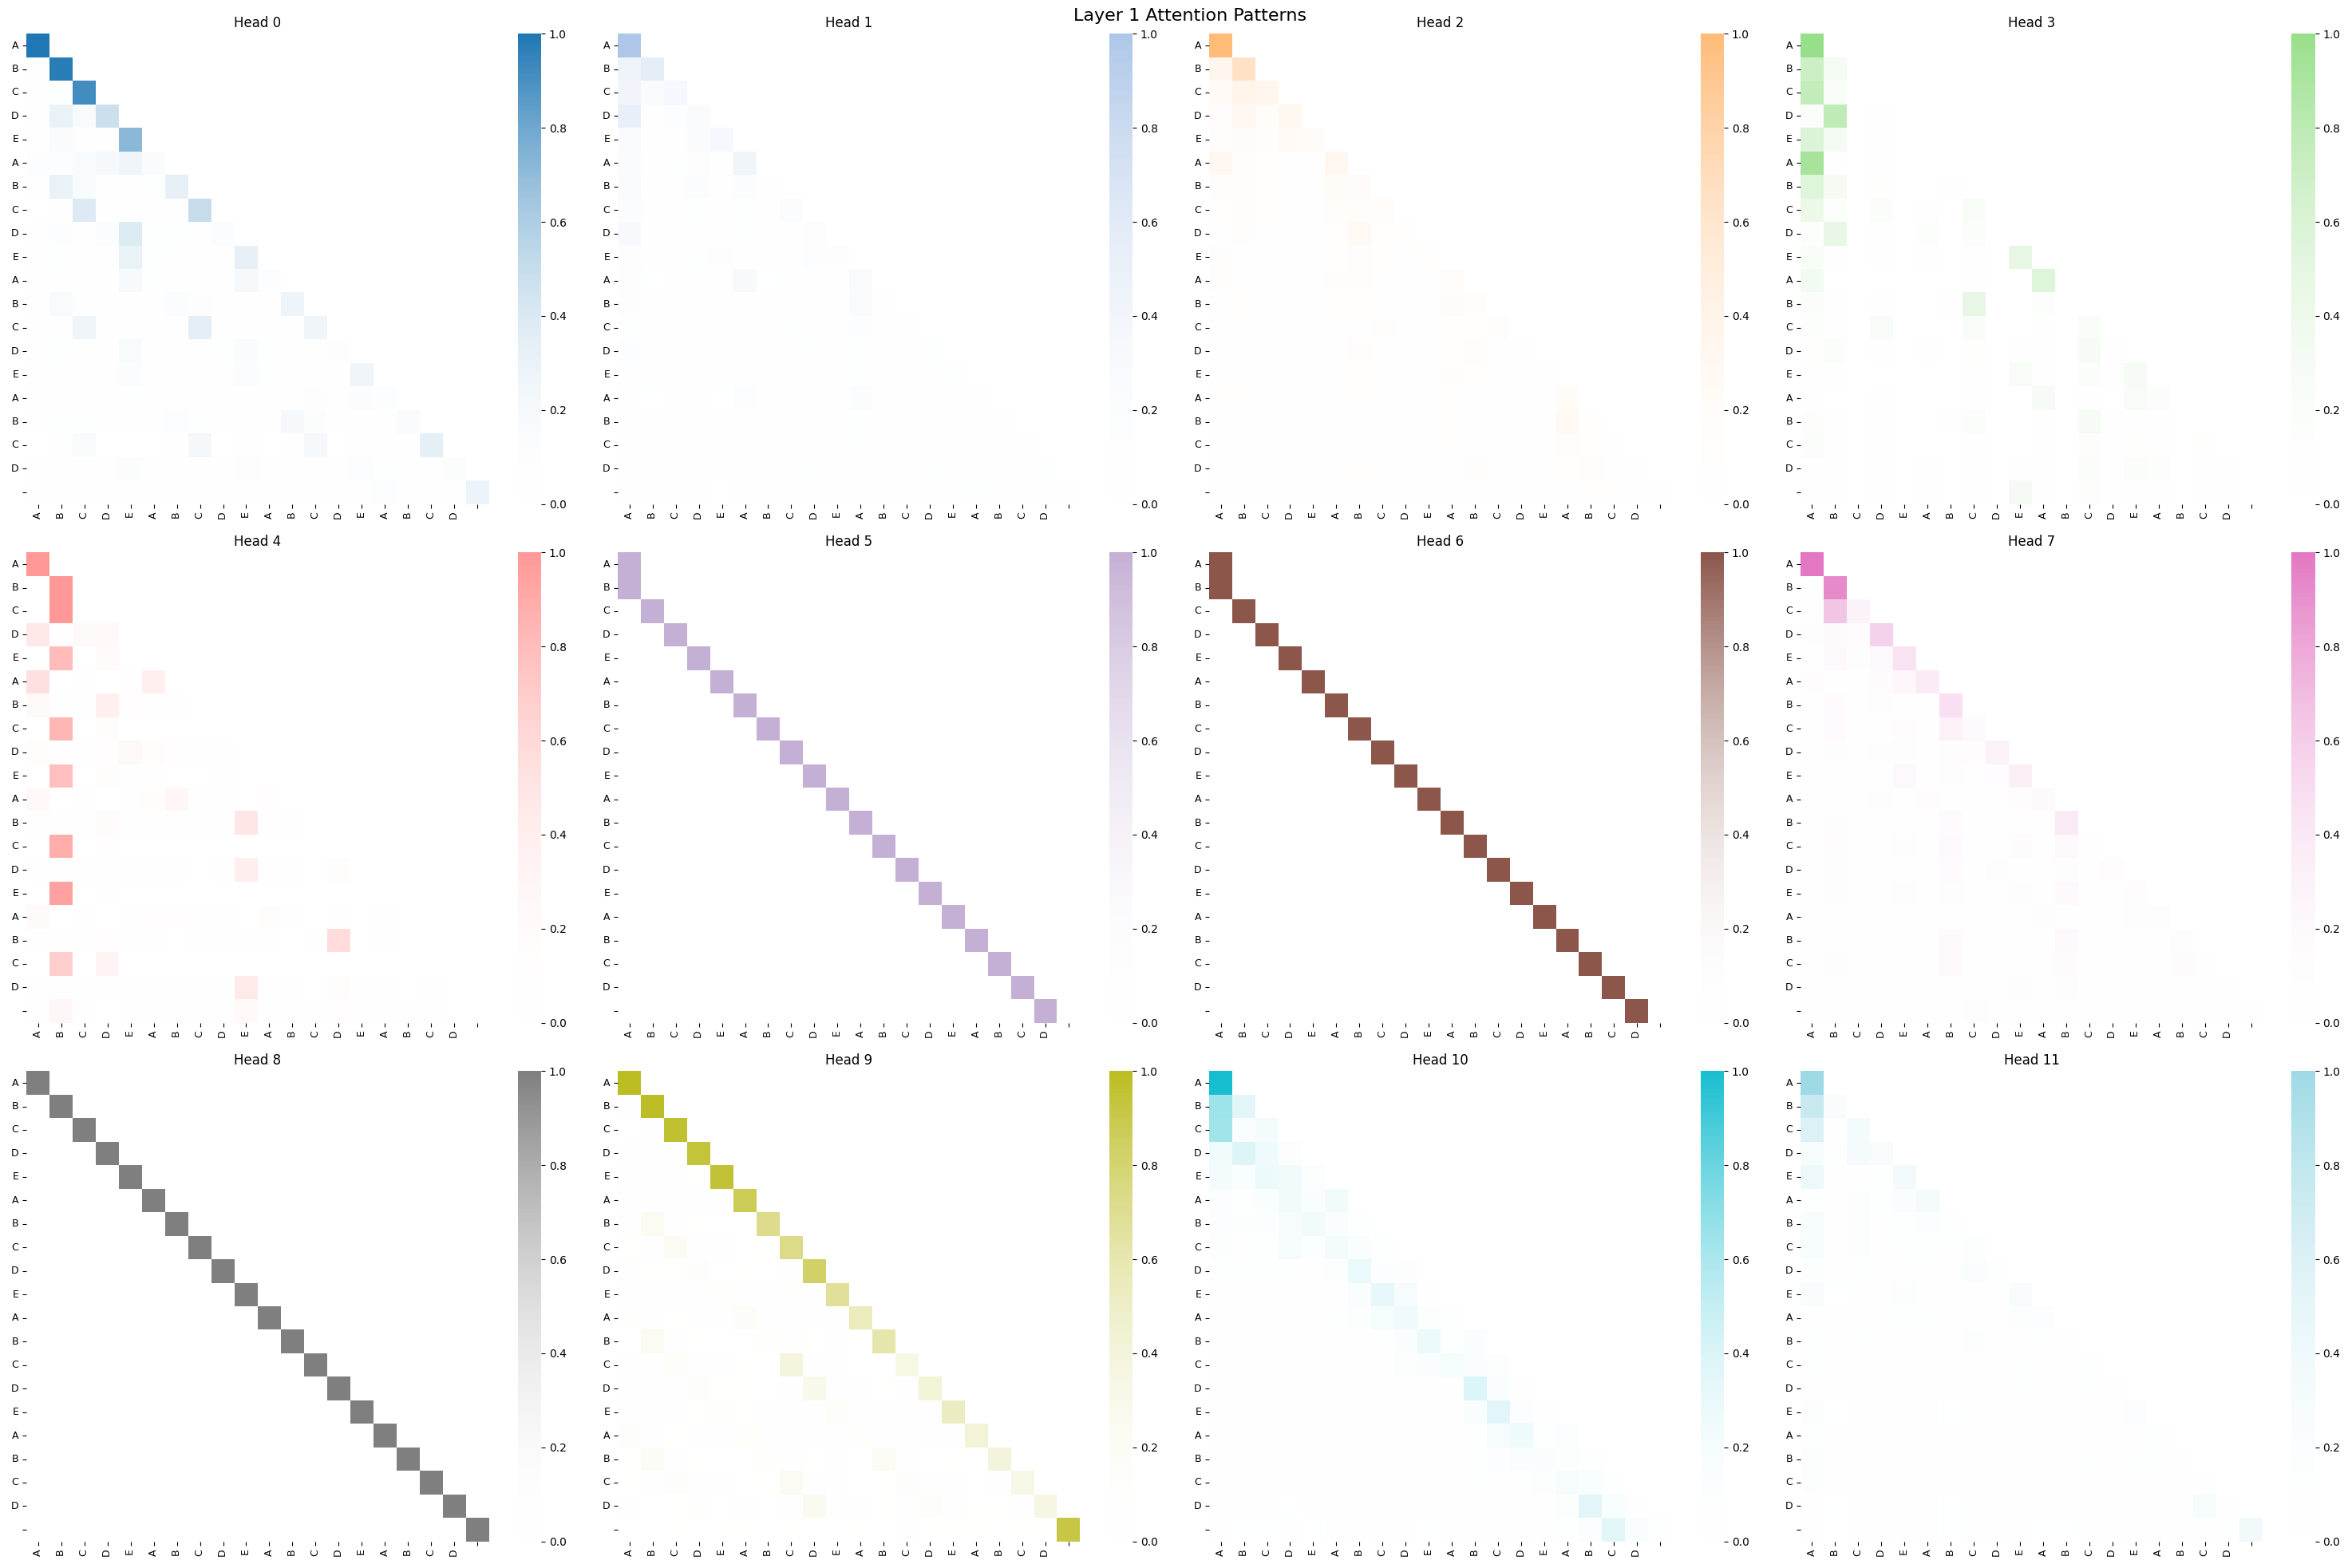

In [113]:
fig = plot_attention_heads(
    cache['pattern'][0], tokens, 'Layer 1 Attention Patterns ', (30, 20))
plt.show()

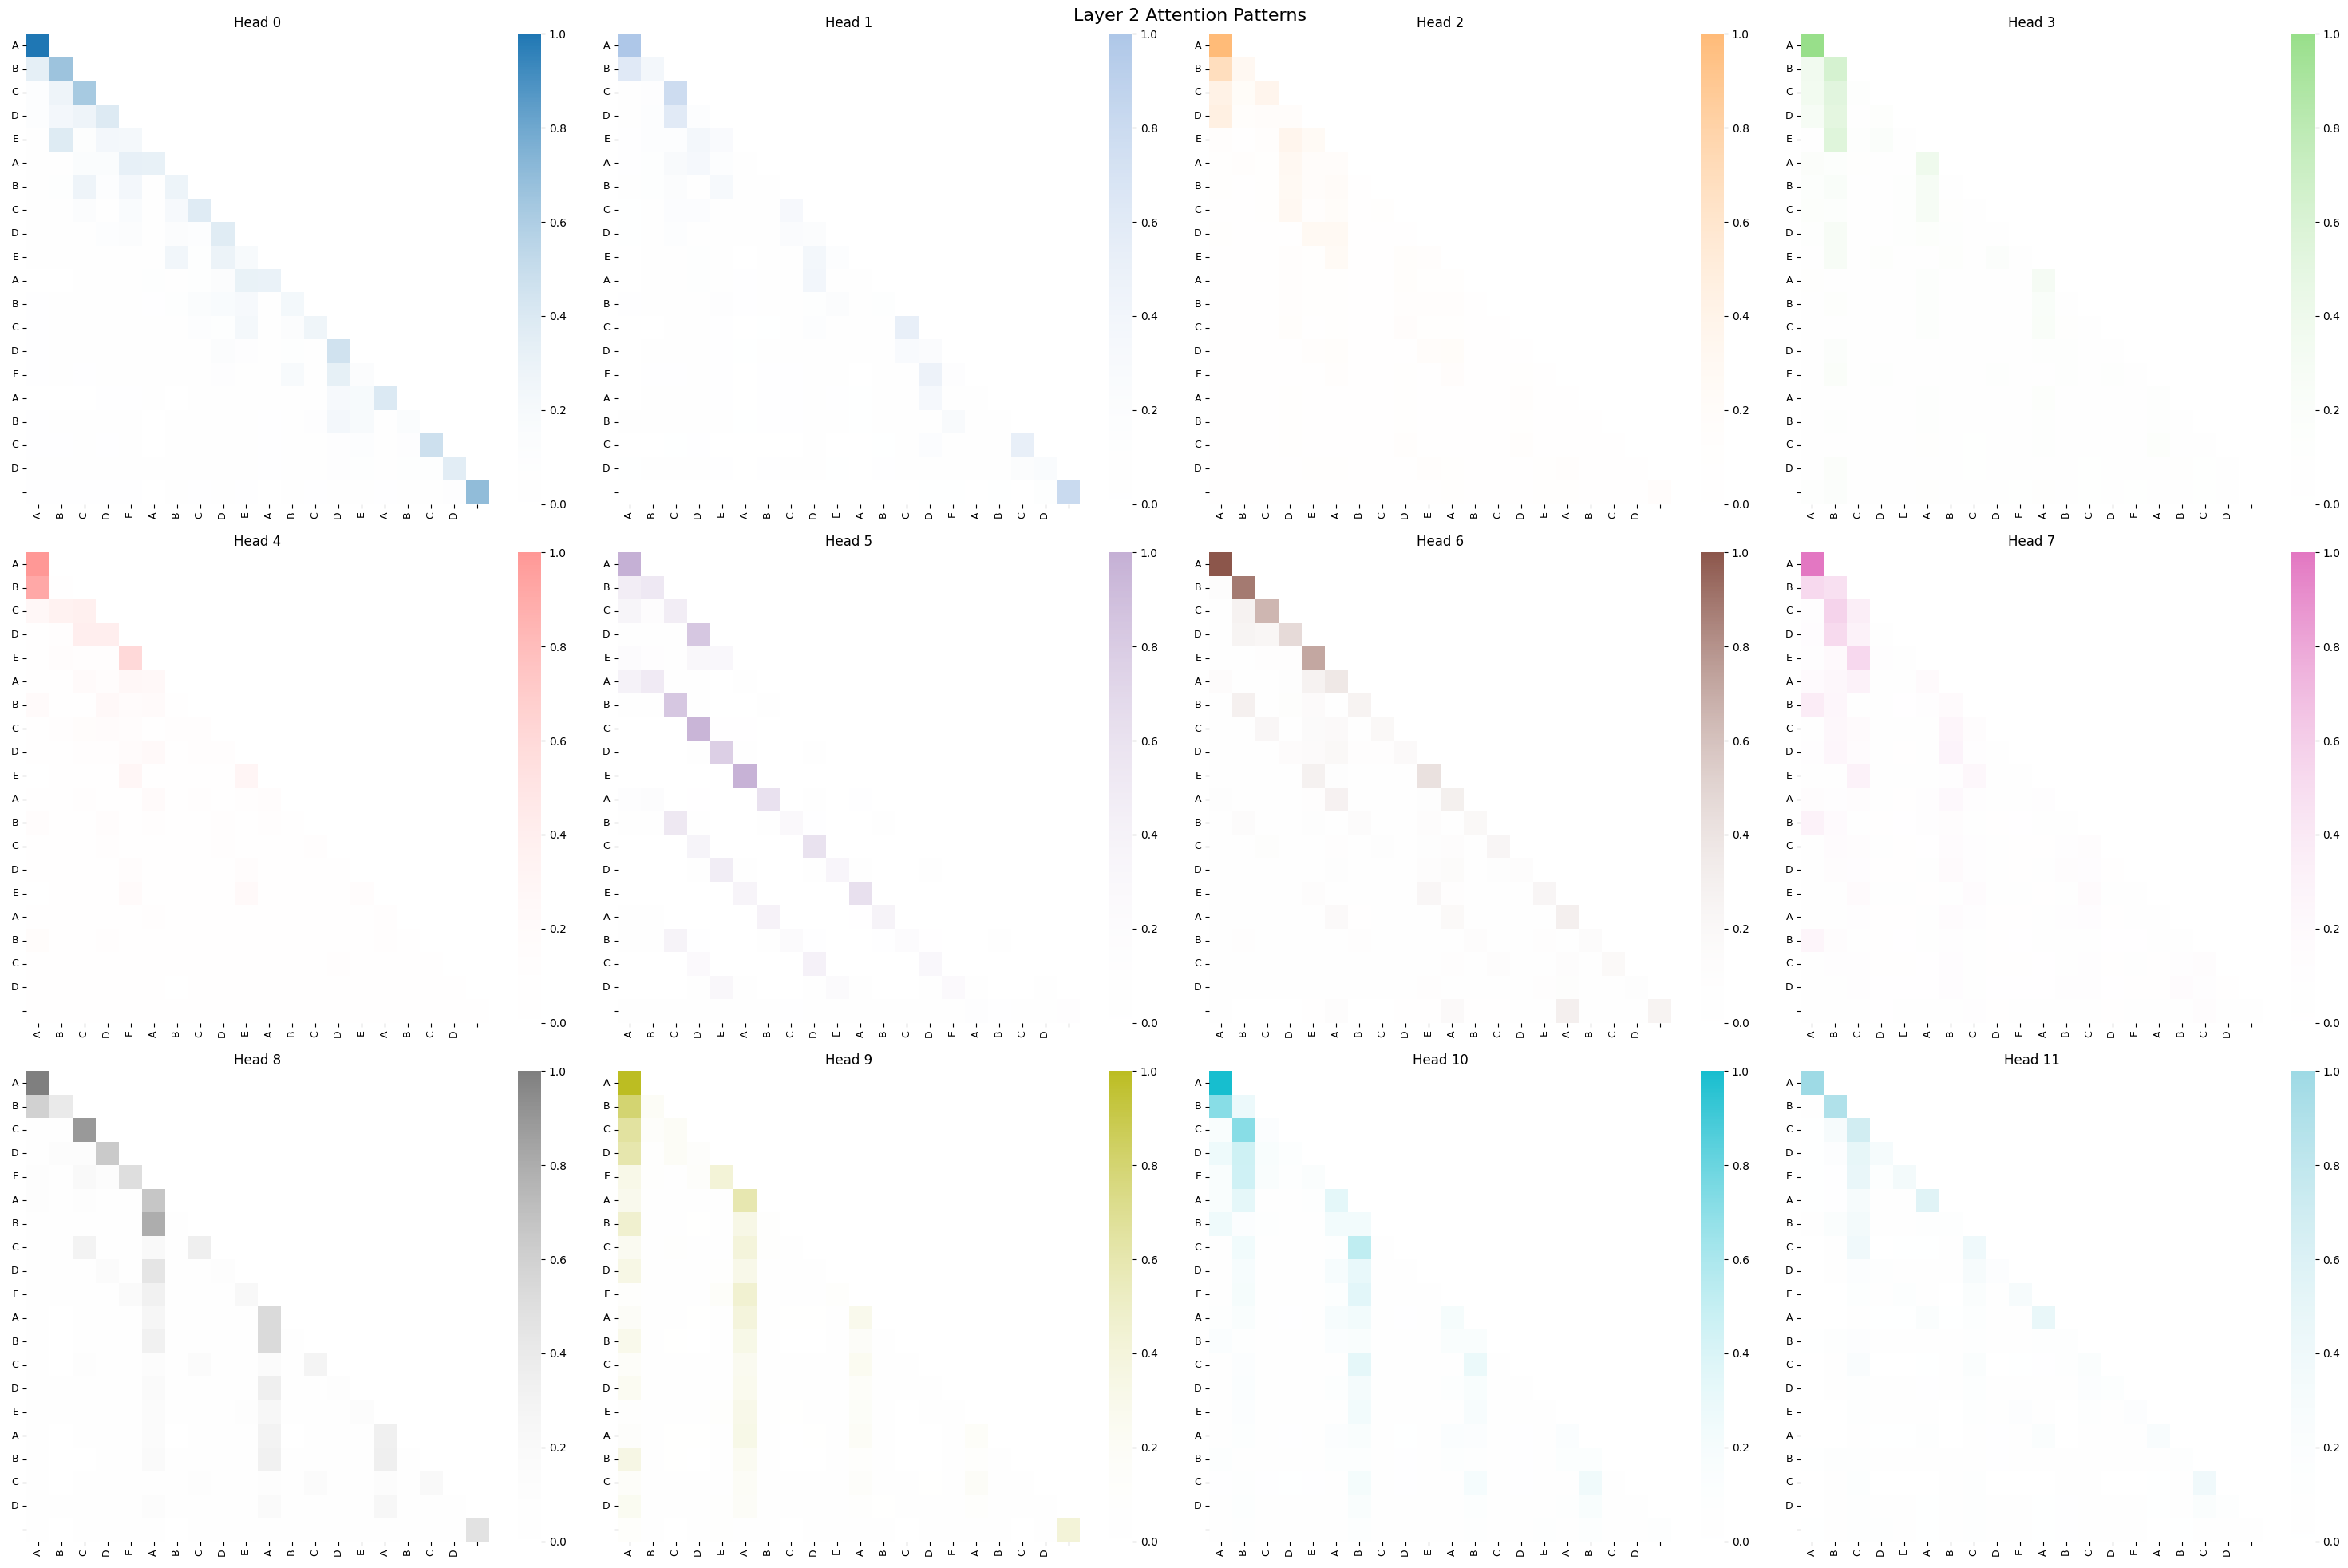

In [114]:
fig = plot_attention_heads(
    cache['pattern'][1], tokens, 'Layer 2 Attention Patterns ', (30, 20))
plt.show()

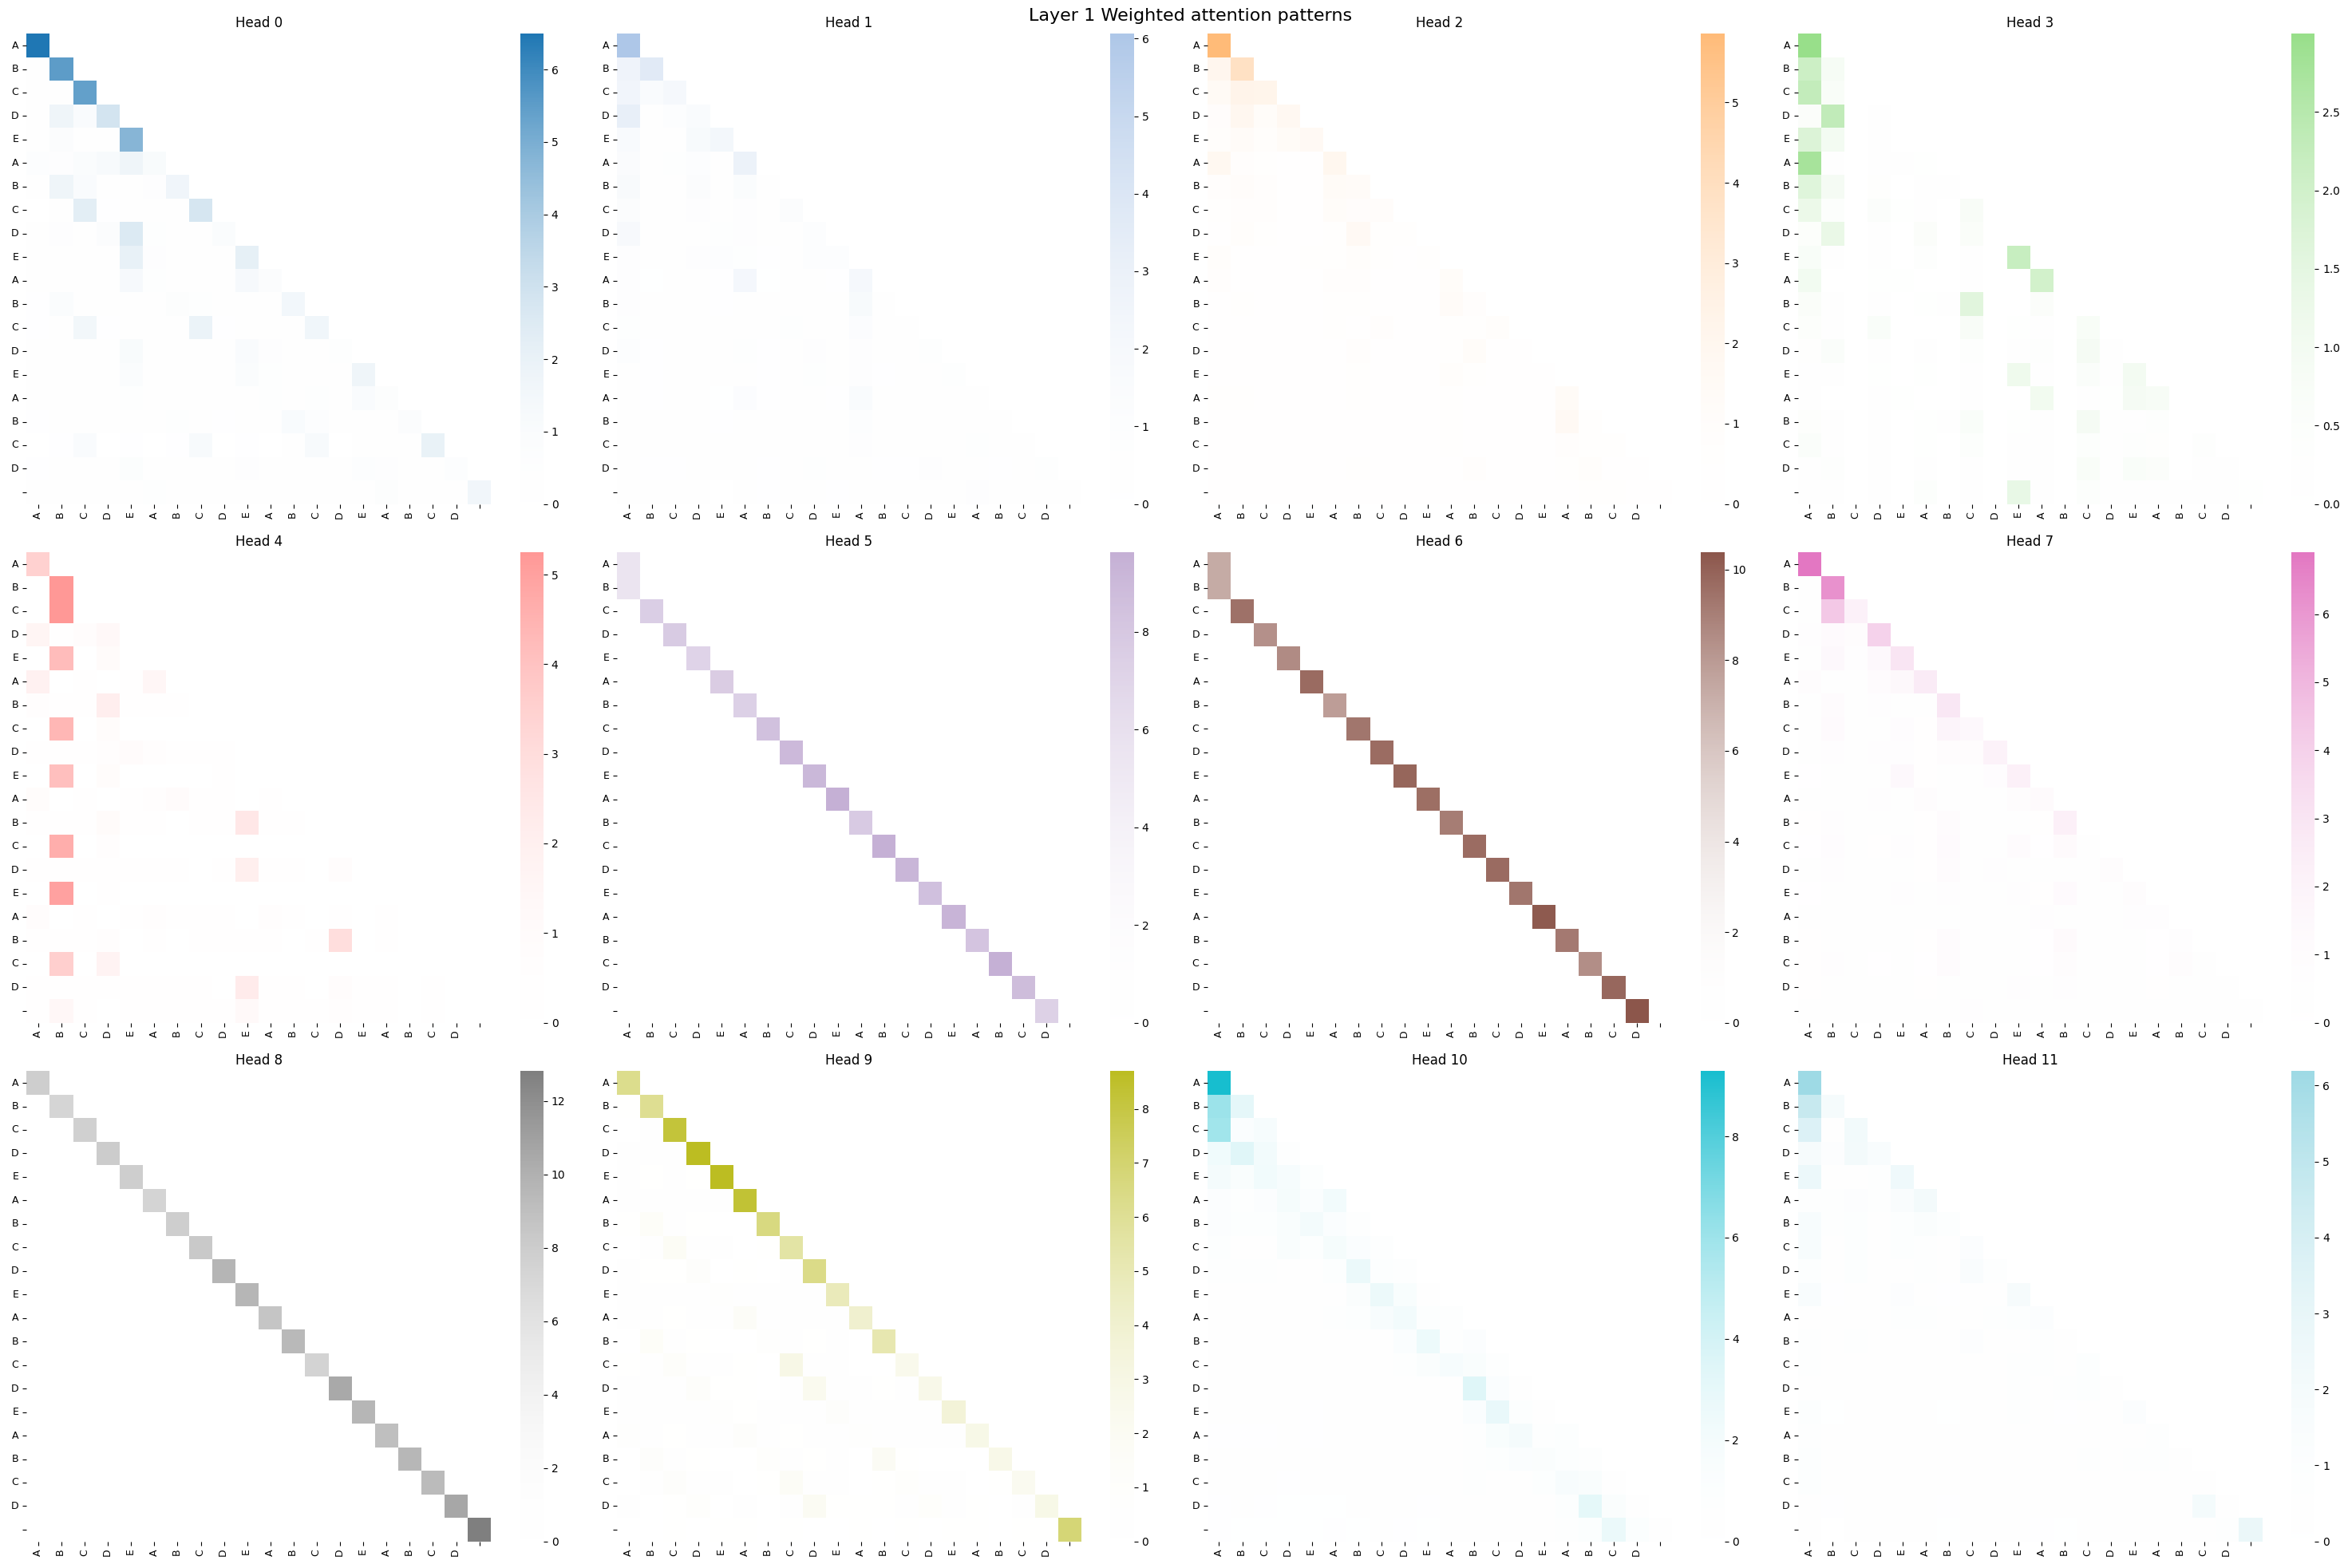

In [115]:
fig = plot_attention_heads(layer_1_weighted_contributions, tokens, 'Layer 1 Weighted attention patterns ', (30, 20))
plt.show()

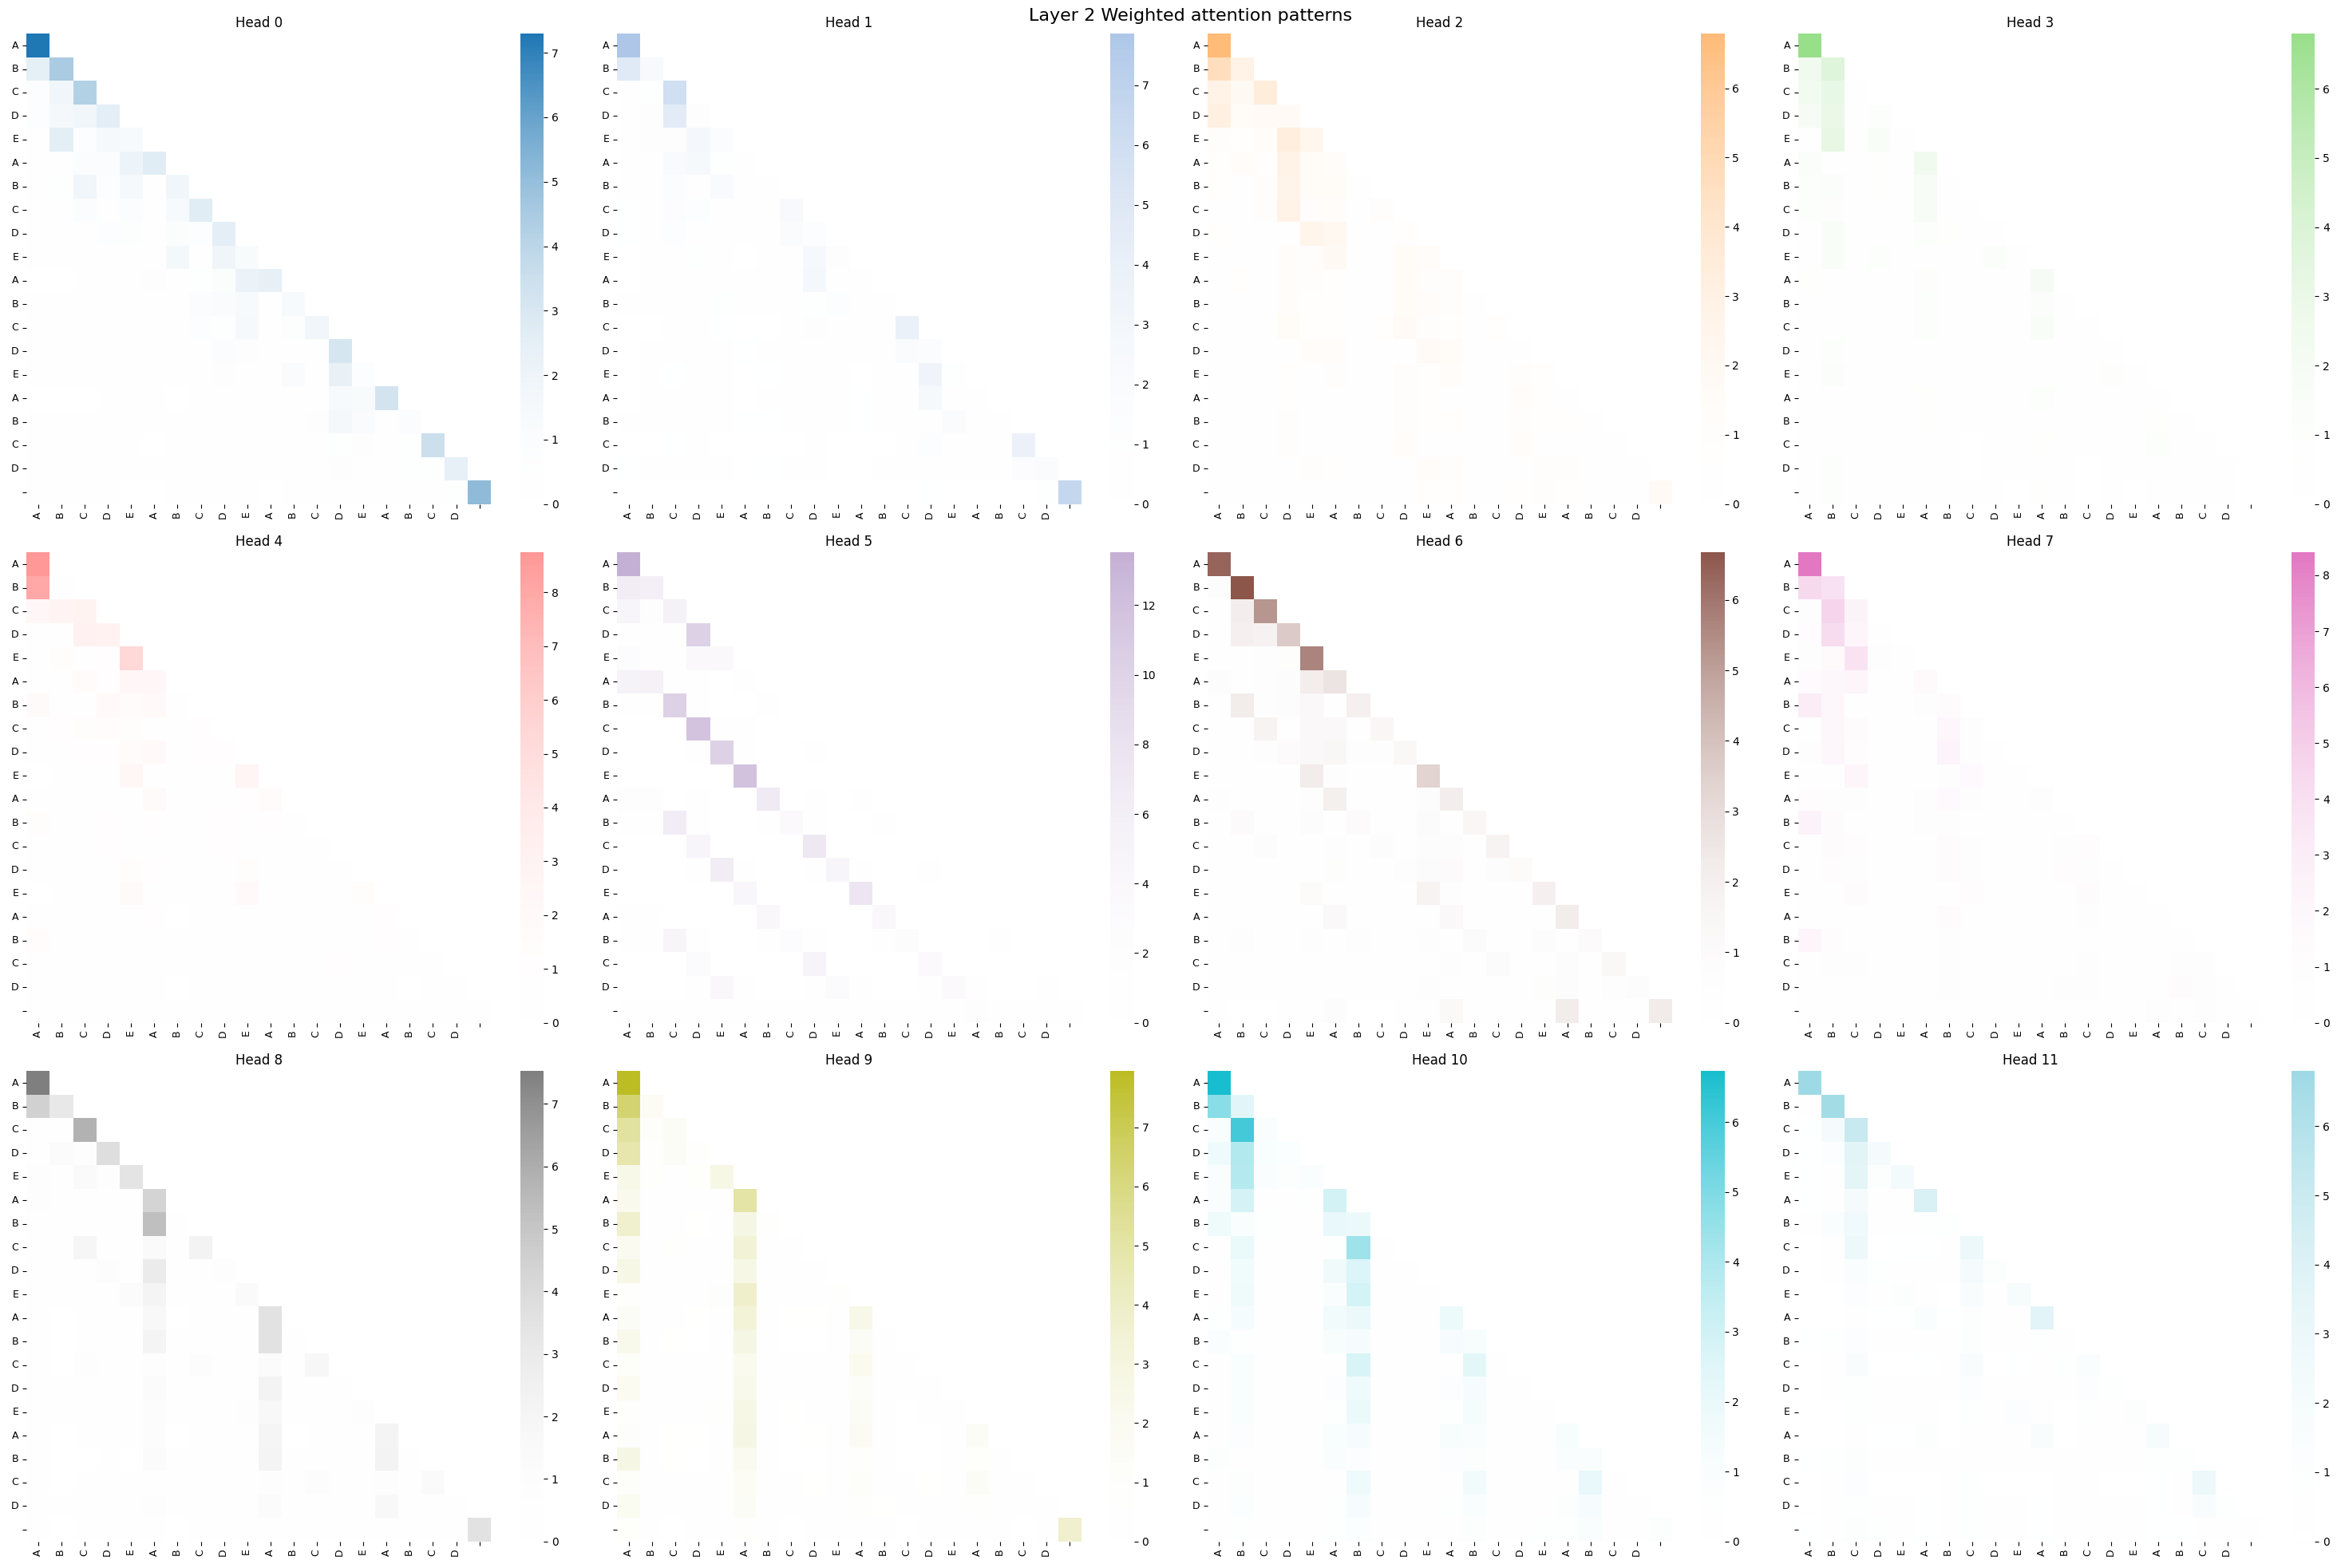

In [116]:

fig = plot_attention_heads(layer_2_weighted_contributions, tokens, 'Layer 2 Weighted attention patterns ', (30, 20))
plt.show()

In [129]:
import json
text = """Mr Dursley was privet driver. 
Mr Dursley was the director of a firm.
Mr Dursley was thin and blonde and had nearly twice the usual amount of neck.
Mr Dursley had a small son called Dudley. 
Mr Dursley"""

token_ids = enc.encode(text)
str_tokens = [enc.decode([t]).replace("\n", "\\n") for t in token_ids]
escaped_tokens = [html.escape(s) for s in str_tokens]

device = next(model.parameters()).device
x = torch.tensor([token_ids], dtype=torch.long, device=device)

model.eval()
with torch.no_grad():
    _, cache = model(x, return_all=True)

weighted_layers = []
head_labels = []

for layer_idx in range(model.num_layers):
    attn = cache['pattern'][layer_idx]
    v = cache['v'][layer_idx]
    v_norm = torch.norm(v, dim=-1).unsqueeze(-2)

    # Weight
    weighted = attn * v_norm
    weighted_layers.append(weighted[0])

    for h in range(model.n_heads):
        head_labels.append(f"L{layer_idx}H{h}")

full_tensor = torch.cat(weighted_layers, dim=0).cpu()
max_per_head = full_tensor.amax(dim=(1, 2)).numpy().tolist()
attn_data = full_tensor.numpy().round(4).tolist()

json_payload = json.dumps({
    "tokens": escaped_tokens,
    "headLabels": head_labels,
    "attention": attn_data,
    "maxPerHead": max_per_head
})

# ==========================================
# 2. GENERATE FINAL HTML
# ==========================================

html_content = f"""
<!DOCTYPE html>
<html lang="en">
<head>
    <meta charset="UTF-8">
    <title>Copying Detector Viz</title>
    <style>
        :root {{
            --bg: #050505;
            --panel: #111;
            --border: #222;
            --accent-cyan: #00f2ff;   /* Active Heads */
            --accent-red: #ff2a2a;    /* Destination (Future) */
            --accent-purple: #d500f9; /* Source (Past) */
        }}

        body {{
            background-color: var(--bg);
            color: #eee;
            font-family: 'Segoe UI', sans-serif;
            margin: 0;
            height: 100vh;
            display: flex;
            overflow: hidden;
        }}

        .sidebar {{
            width: 300px;
            background: var(--panel);
            border-right: 1px solid var(--border);
            padding: 20px;
            display: flex;
            flex-direction: column;
            gap: 20px;
        }}
        
        #zoomCanvas {{
            width: 100%;
            aspect-ratio: 1;
            background: #000;
            border: 1px solid #333;
            image-rendering: pixelated;
        }}

        .sidebar-text {{ font-size: 13px; color: #888; line-height: 1.5; }}
        .legend-box {{ display: inline-block; width: 10px; height: 10px; margin-right: 5px; }}

        .main-content {{
            flex: 1;
            padding: 40px;
            overflow-y: auto;
            display: flex;
            flex-direction: column;
            gap: 30px;
        }}

        .heads-grid {{
            display: grid;
            grid-template-columns: repeat({model.n_heads}, 1fr);
            gap: 6px;
        }}

        .head-card {{
            background: #0a0a0a;
            border: 1px solid #222;
            aspect-ratio: 1;
            position: relative;
            cursor: pointer;
            transition: all 0.2s;
        }}
        .head-card canvas {{ opacity: 0.3; width: 100%; height: 100%; }}
        
        /* Active Head Style */
        .head-card.active {{
            border-color: var(--accent-cyan);
            box-shadow: 0 0 15px rgba(0, 242, 255, 0.3);
            transform: scale(1.1);
            z-index: 10;
        }}
        .head-card.active canvas {{ opacity: 1.0; }}
        .head-card.dimmed {{ opacity: 0.1; }}

        .text-area {{
            background: var(--panel);
            padding: 30px;
            border-radius: 4px;
            line-height: 2.2;
            font-family: 'Consolas', monospace;
            font-size: 15px;
            white-space: pre-wrap;
        }}

        .token {{
            padding: 2px 3px;
            border-radius: 3px;
            cursor: pointer;
            color: #666;
            border: 1px solid transparent;
            transition: all 0.1s;
        }}
        .token:hover {{ color: #fff; border-color: #fff; }}
        
        /* --- HIGHLIGHT STYLES --- */
        
        /* RED: Destination (When hovering a Head) */
        .token.highlight-dest {{
            background-color: rgba(255, 42, 42, 0.3);
            color: #fff;
            box-shadow: 0 0 5px rgba(255, 42, 42, 0.5);
        }}

        /* PURPLE: Source (When hovering a Token) */
        .token.highlight-source {{
            background-color: rgba(213, 0, 249, 0.4); /* Purple */
            color: #fff;
            box-shadow: 0 0 8px rgba(213, 0, 249, 0.6);
            font-weight: bold;
        }}

        /* The token currently being hovered */
        .token.current {{
            border: 1px solid yellow !important;
            background: rgba(255, 255, 0, 0.1);
            color: #fff;
        }}
        
        .locked {{ border: 1px solid #fff !important; }}

    </style>
</head>
<body>

    <div class="sidebar">
        <div>
            <div id="zoomLabel" style="font-weight:bold; color:#fff; margin-bottom:10px;">Hover a Head</div>
            <canvas id="zoomCanvas" width="{len(str_tokens)}" height="{len(str_tokens)}"></canvas>
        </div>
        <div class="sidebar-text">
            <p><strong>Mode 1: Hover Head</strong><br>
            <span class="legend-box" style="background:var(--accent-red)"></span>Red Text: Destination<br>
            "Where is this head writing to?"</p>
            
            <p><strong>Mode 2: Hover Token</strong><br>
            <span class="legend-box" style="background:var(--accent-cyan)"></span>Cyan Heads: Active Heads<br>
            <span class="legend-box" style="background:var(--accent-purple)"></span>Purple Text: Source<br>
            "Where did info come FROM?"</p>
            
            <p><em>Click to Lock view.</em></p>
        </div>
    </div>

    <div class="main-content" id="mainArea">
        <div>
            <div style="font-size:10px; color:#555; margin-bottom:5px;">ATTENTION HEADS</div>
            <div id="headsGrid" class="heads-grid"></div>
        </div>

        <div>
            <div style="font-size:10px; color:#555; margin-bottom:5px;">PROMPT SEQUENCE</div>
            <div id="textContainer" class="text-area"></div>
        </div>
    </div>

    <script>
        const data = {json_payload};
        const nTokens = data.tokens.length;
        
        let lockedHead = null;
        let lockedToken = null;

        const headsGrid = document.getElementById('headsGrid');
        const textDiv = document.getElementById('textContainer');
        const zoomCanvas = document.getElementById('zoomCanvas');
        const zoomCtx = zoomCanvas.getContext('2d');
        const zoomLabel = document.getElementById('zoomLabel');

        // --- INIT ---
        data.headLabels.forEach((label, hIdx) => {{
            const div = document.createElement('div');
            div.className = 'head-card';
            div.id = `h-${{hIdx}}`;
            
            const cvs = document.createElement('canvas');
            cvs.width = nTokens;
            cvs.height = nTokens;
            drawMiniHeatmap(cvs, hIdx);
            div.appendChild(cvs);
            headsGrid.appendChild(div);

            div.addEventListener('mouseenter', () => {{ if(!lockedHead && !lockedToken) setHeadFocus(hIdx); }});
            div.addEventListener('mouseleave', () => {{ if(!lockedHead && !lockedToken) clearFocus(); }});
            div.addEventListener('click', (e) => {{
                e.stopPropagation();
                if(lockedHead === hIdx) unlock();
                else {{ unlock(); lockedHead = hIdx; setHeadFocus(hIdx); div.classList.add('locked'); }}
            }});
        }});

        data.tokens.forEach((str, tIdx) => {{
            const span = document.createElement('span');
            span.className = 'token';
            span.id = `t-${{tIdx}}`;
            span.innerHTML = str;
            textDiv.appendChild(span);

            span.addEventListener('mouseenter', () => {{ if(!lockedHead && !lockedToken) setTokenFocus(tIdx); }});
            span.addEventListener('mouseleave', () => {{ if(!lockedHead && !lockedToken) clearFocus(); }});
            span.addEventListener('click', (e) => {{
                e.stopPropagation();
                if(lockedToken === tIdx) unlock();
                else {{ unlock(); lockedToken = tIdx; setTokenFocus(tIdx); span.classList.add('locked'); }}
            }});
        }});

        document.getElementById('mainArea').addEventListener('click', unlock);

        // --- DRAWING HELPERS ---
        function drawMiniHeatmap(canvas, hIdx) {{
            const ctx = canvas.getContext('2d');
            const imgData = ctx.createImageData(nTokens, nTokens);
            const matrix = data.attention[hIdx];
            const max = data.maxPerHead[hIdx] || 1;

            for(let y=0; y<nTokens; y++) {{
                for(let x=0; x<nTokens; x++) {{
                    let val = matrix[y][x];
                    let norm = Math.pow(val/max, 2); // Contrast
                    const i = (y * nTokens + x) * 4;
                    imgData.data[i] = 100;
                    imgData.data[i+1] = 255;
                    imgData.data[i+2] = 255;
                    imgData.data[i+3] = norm * 255;
                }}
            }}
            ctx.putImageData(imgData, 0, 0);
        }}

        function drawZoomedMatrix(hIdx) {{
            if(hIdx === null) {{
                zoomCtx.fillStyle = '#000';
                zoomCtx.fillRect(0,0,nTokens,nTokens);
                return;
            }}
            const matrix = data.attention[hIdx];
            const max = data.maxPerHead[hIdx] || 1;
            const imgData = zoomCtx.createImageData(nTokens, nTokens);
            for(let i=0; i<nTokens*nTokens*4; i+=4) {{
                const val = matrix[Math.floor(i/4/nTokens)][(i/4)%nTokens];
                const norm = val/max;
                imgData.data[i] = norm * 50;
                imgData.data[i+1] = norm * 200;
                imgData.data[i+2] = norm * 255;
                imgData.data[i+3] = 255;
            }}
            zoomCtx.putImageData(imgData, 0, 0);
        }}

        // --- INTERACTION ---

        function setHeadFocus(hIdx) {{
            // MODE: DESTINATION (RED)
            zoomLabel.innerText = data.headLabels[hIdx];
            drawZoomedMatrix(hIdx);

            const matrix = data.attention[hIdx];
            // Sum destination columns
            const destScores = matrix.map(row => row.reduce((a,b)=>a+b, 0));
            const max = Math.max(...destScores, 0.0001);

            data.tokens.forEach((_, t) => {{
                let intensity = destScores[t] / max;
                if(intensity < 0.2) intensity = 0;
                else intensity = Math.pow(intensity, 2);

                if(intensity > 0.01) {{
                    const el = document.getElementById(`t-${{t}}`);
                    el.classList.add('highlight-dest');
                    el.style.backgroundColor = `rgba(255, 42, 42, ${{intensity * 0.5}})`;
                }}
            }});
        }}

        function setTokenFocus(tIdx) {{
            // MODE: SOURCE (PURPLE) & HEADS (CYAN)
            zoomLabel.innerText = "Current: " + tIdx;
            drawZoomedMatrix(null); // No specific head matrix to show

            // 1. Highlight Current Token (Yellow Border)
            document.getElementById(`t-${{tIdx}}`).classList.add('current');

            // 2. Identify Active Heads (Cyan)
            const headScores = data.attention.map(m => m[tIdx].reduce((a,b)=>a+b, 0));
            const maxHead = Math.max(...headScores, 0.0001);

            data.headLabels.forEach((_, h) => {{
                let intensity = headScores[h] / maxHead;
                intensity = Math.pow(intensity, 3); // High contrast
                
                const el = document.getElementById(`h-${{h}}`);
                if(intensity > 0.05) {{
                    el.classList.add('active');
                    el.style.opacity = intensity + 0.3;
                }} else {{
                    el.classList.add('dimmed');
                }}
            }});

            // 3. Identify SOURCE Tokens (Purple)
            // We need to sum up where ALL heads are looking FROM
            let sourceScores = new Array(nTokens).fill(0);
            
            data.attention.forEach(matrix => {{
                // matrix[tIdx] is the row of Attention FROM sources TO our tIdx
                matrix[tIdx].forEach((val, srcIdx) => {{
                    sourceScores[srcIdx] += val;
                }});
            }});

            // Normalize Source Scores
            // Filter self-attention to see copying better? (Optional, kept raw here)
            const maxSource = Math.max(...sourceScores, 0.0001);

            data.tokens.forEach((_, sIdx) => {{
                if(sIdx === tIdx) return; // Skip self for clearer viz of others

                let intensity = sourceScores[sIdx] / maxSource;
                if(intensity < 0.1) intensity = 0;
                else intensity = Math.pow(intensity, 2);

                if(intensity > 0.01) {{
                    const el = document.getElementById(`t-${{sIdx}}`);
                    el.classList.add('highlight-source');
                    el.style.backgroundColor = `rgba(213, 0, 249, ${{intensity * 0.6}})`;
                }}
            }});
        }}

        function clearFocus() {{
            drawZoomedMatrix(null);
            zoomLabel.innerText = "Hover a Head";

            // Clear Classes
            document.querySelectorAll('.head-card').forEach(e => {{
                e.classList.remove('active', 'dimmed');
                e.style.opacity = '';
            }});
            document.querySelectorAll('.token').forEach(e => {{
                e.classList.remove('highlight-dest', 'highlight-source', 'current');
                e.style.backgroundColor = '';
                e.style.opacity = '1';
            }});
        }}

        function unlock() {{
            lockedHead = null;
            lockedToken = null;
            document.querySelectorAll('.locked').forEach(e => e.classList.remove('locked'));
            clearFocus();
        }}
    </script>
</body>
</html>
"""

with open("viz.html", "w", encoding="utf-8") as f:
    f.write(html_content)

print("Generated: viz.html")

Generated: viz.html


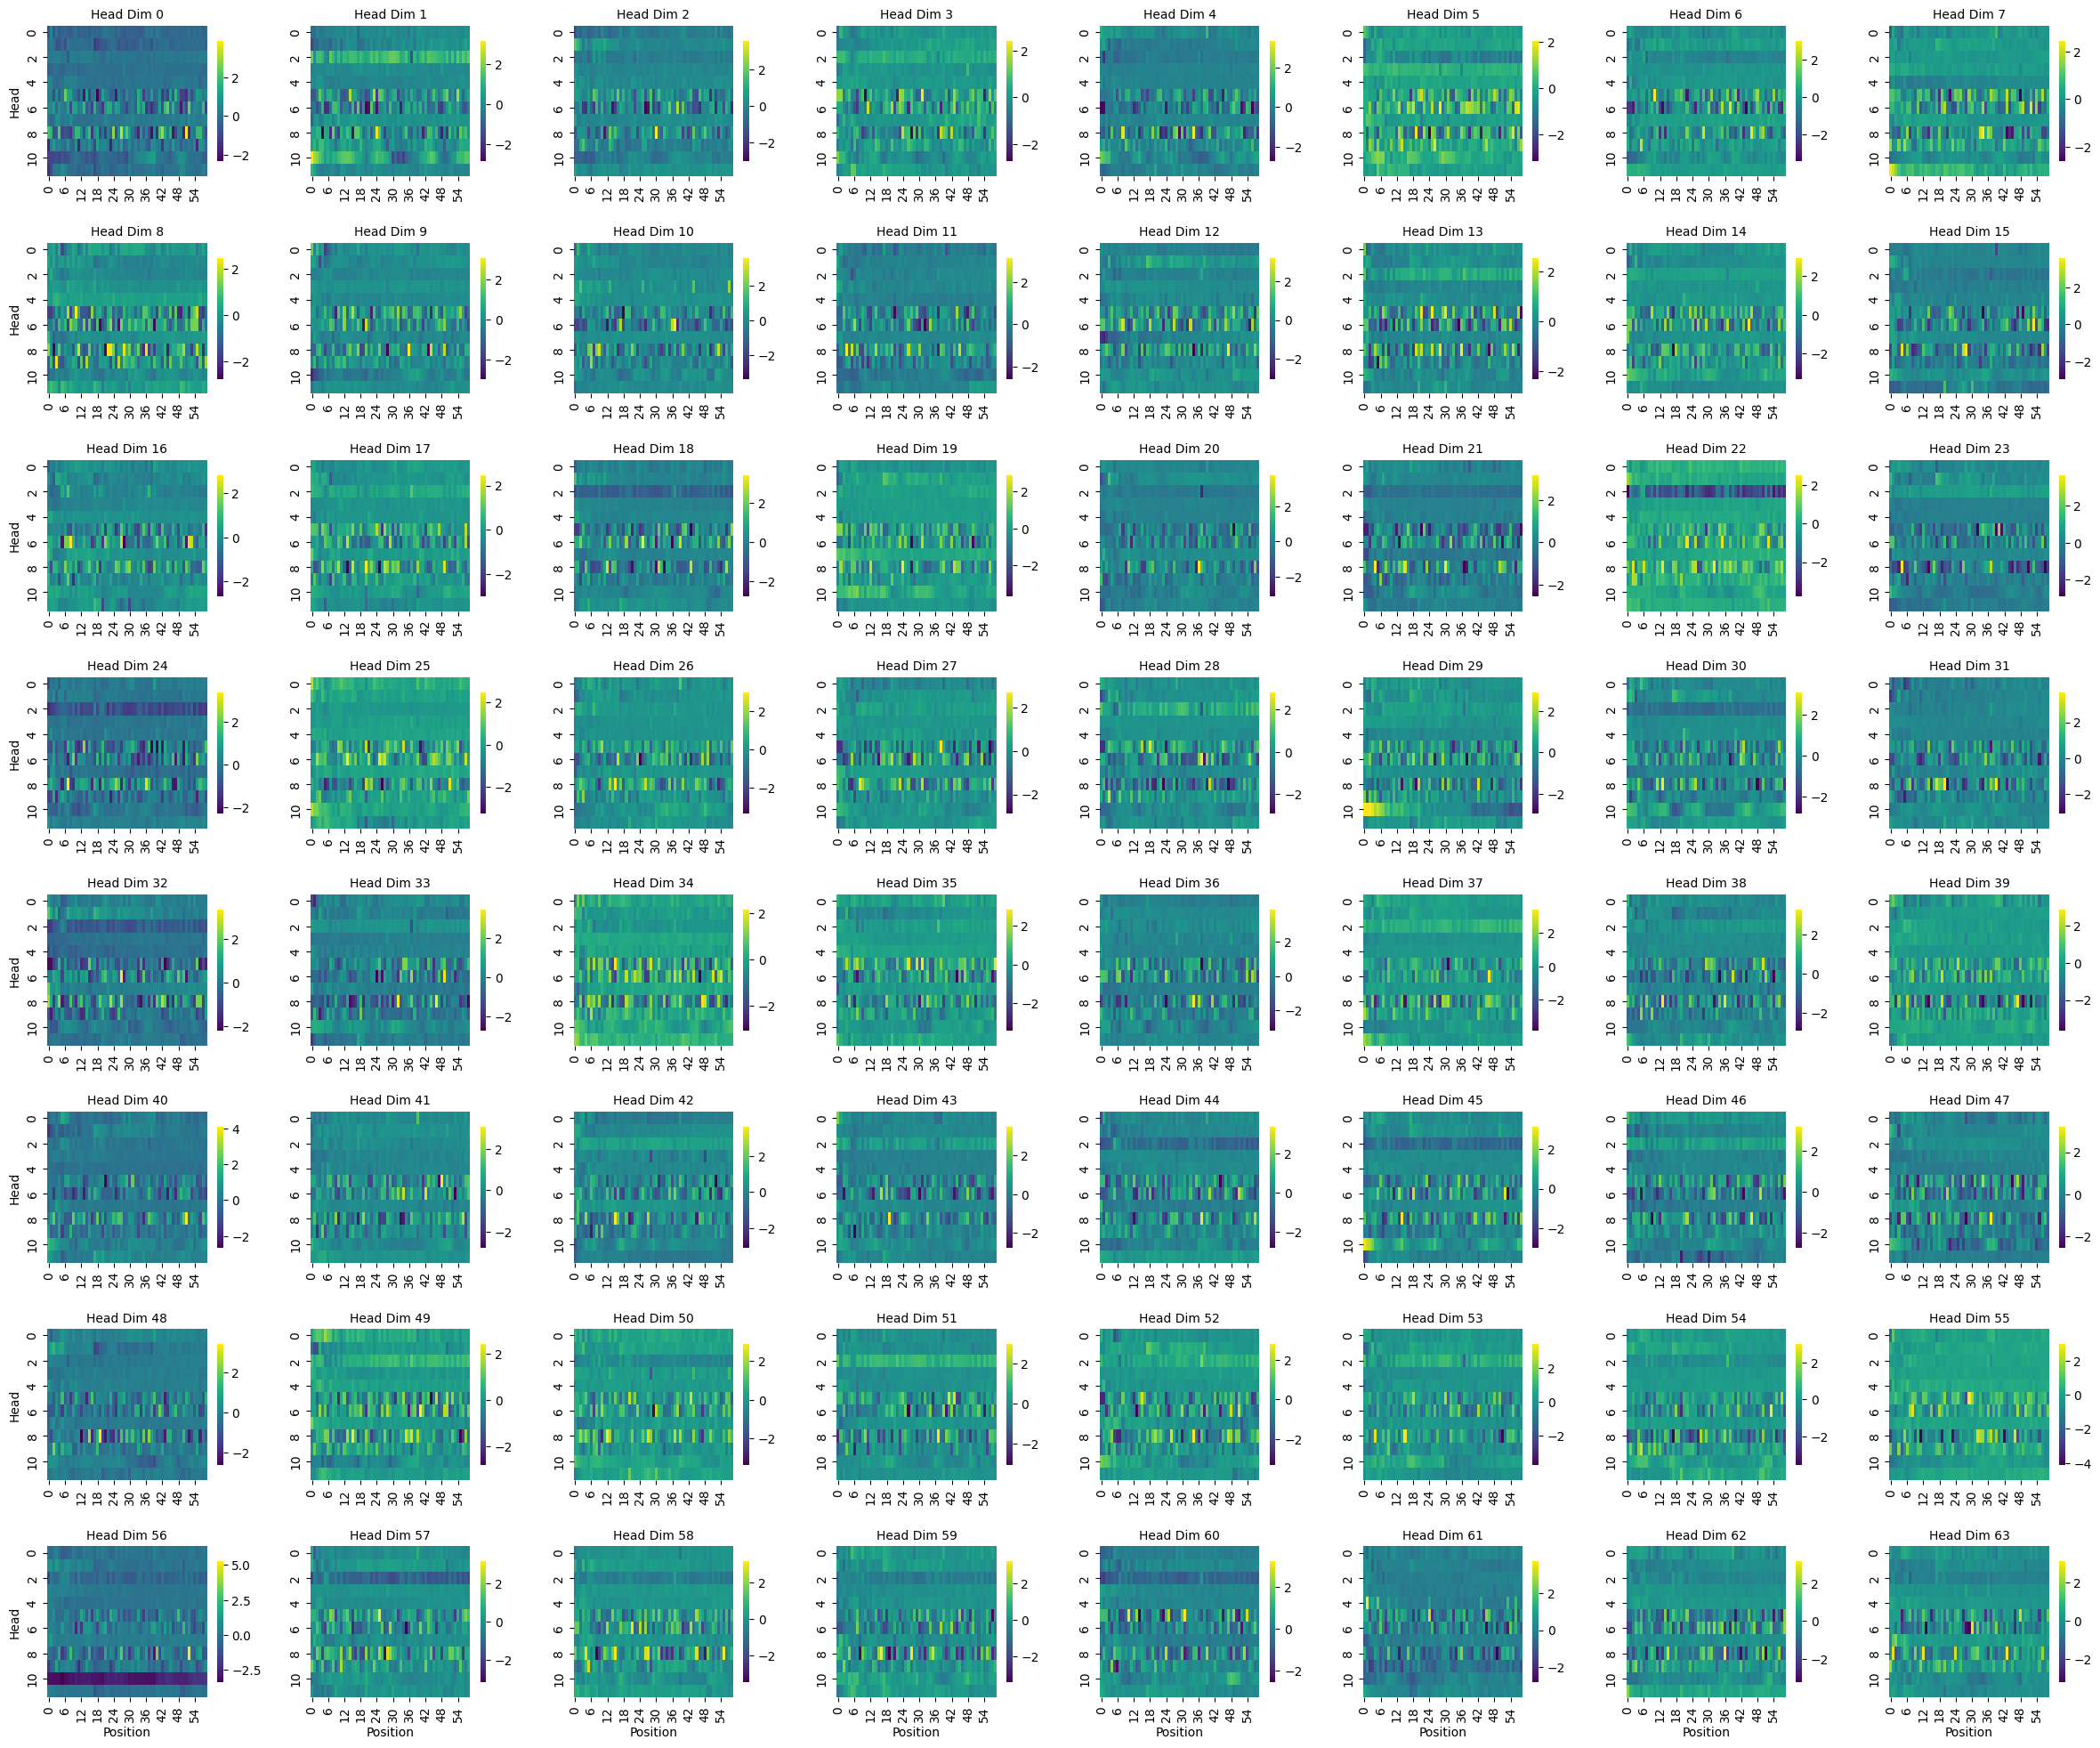

In [118]:
def visualize_attention_dimensions(z_output, n_heads, d_head, dimensions_to_show=None):
    # Reshape to [batch_size, seq_len, n_heads, d_head]
    reshaped = z_output.cpu().numpy().reshape(z_output.shape[0], z_output.shape[1], n_heads, d_head)

    # Default to showing all dimensions if not specified
    if dimensions_to_show is None:
        dimensions_to_show = list(range(d_head))

    n_dims_to_show = len(dimensions_to_show)
    if n_dims_to_show == 0:
        print("No dimensions to show.")
        return None

    # --- Key Change: Calculate grid size (rows, cols) ---
    n_cols = int(np.ceil(np.sqrt(n_dims_to_show)))
    n_rows = int(np.ceil(n_dims_to_show / n_cols))

    # --- Key Change: Create a grid of subplots ---
    # Adjust figure size dynamically based on the grid
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 3, n_rows * 2.5))

    # Flatten the 2D axes array into a 1D array for easy iteration
    # This handles cases where n_rows or n_cols is 1
    axes = axes.flatten() if n_dims_to_show > 1 else [axes]

    for i, dim in enumerate(dimensions_to_show):
        ax = axes[i]
        sns.heatmap(
            reshaped[0, :, :, dim].T,  # Transpose to have heads on y-axis
            ax=ax,
            cmap='viridis',
            cbar=True,
            cbar_kws={"shrink": 0.8} # Make colorbars a bit smaller
        )
        ax.set_title(f'Head Dim {dim}', fontsize=10)
        if i % n_cols == 0:
            ax.set_ylabel('Head')
        else:
            ax.set_ylabel('')
        
        # Set x-label (Position) only for the bottom row
        if i >= (n_rows - 1) * n_cols:
            ax.set_xlabel('Position')
        else:
            ax.set_xlabel('')

    # --- Key Change: Hide any unused subplots in the grid ---
    for i in range(n_dims_to_show, n_rows * n_cols):
        axes[i].axis('off')

    plt.tight_layout(pad=2.0) # Add padding to prevent title overlap
    return fig

fig_all = visualize_attention_dimensions(cache['z'][0], n_heads, d_head)
plt.show()

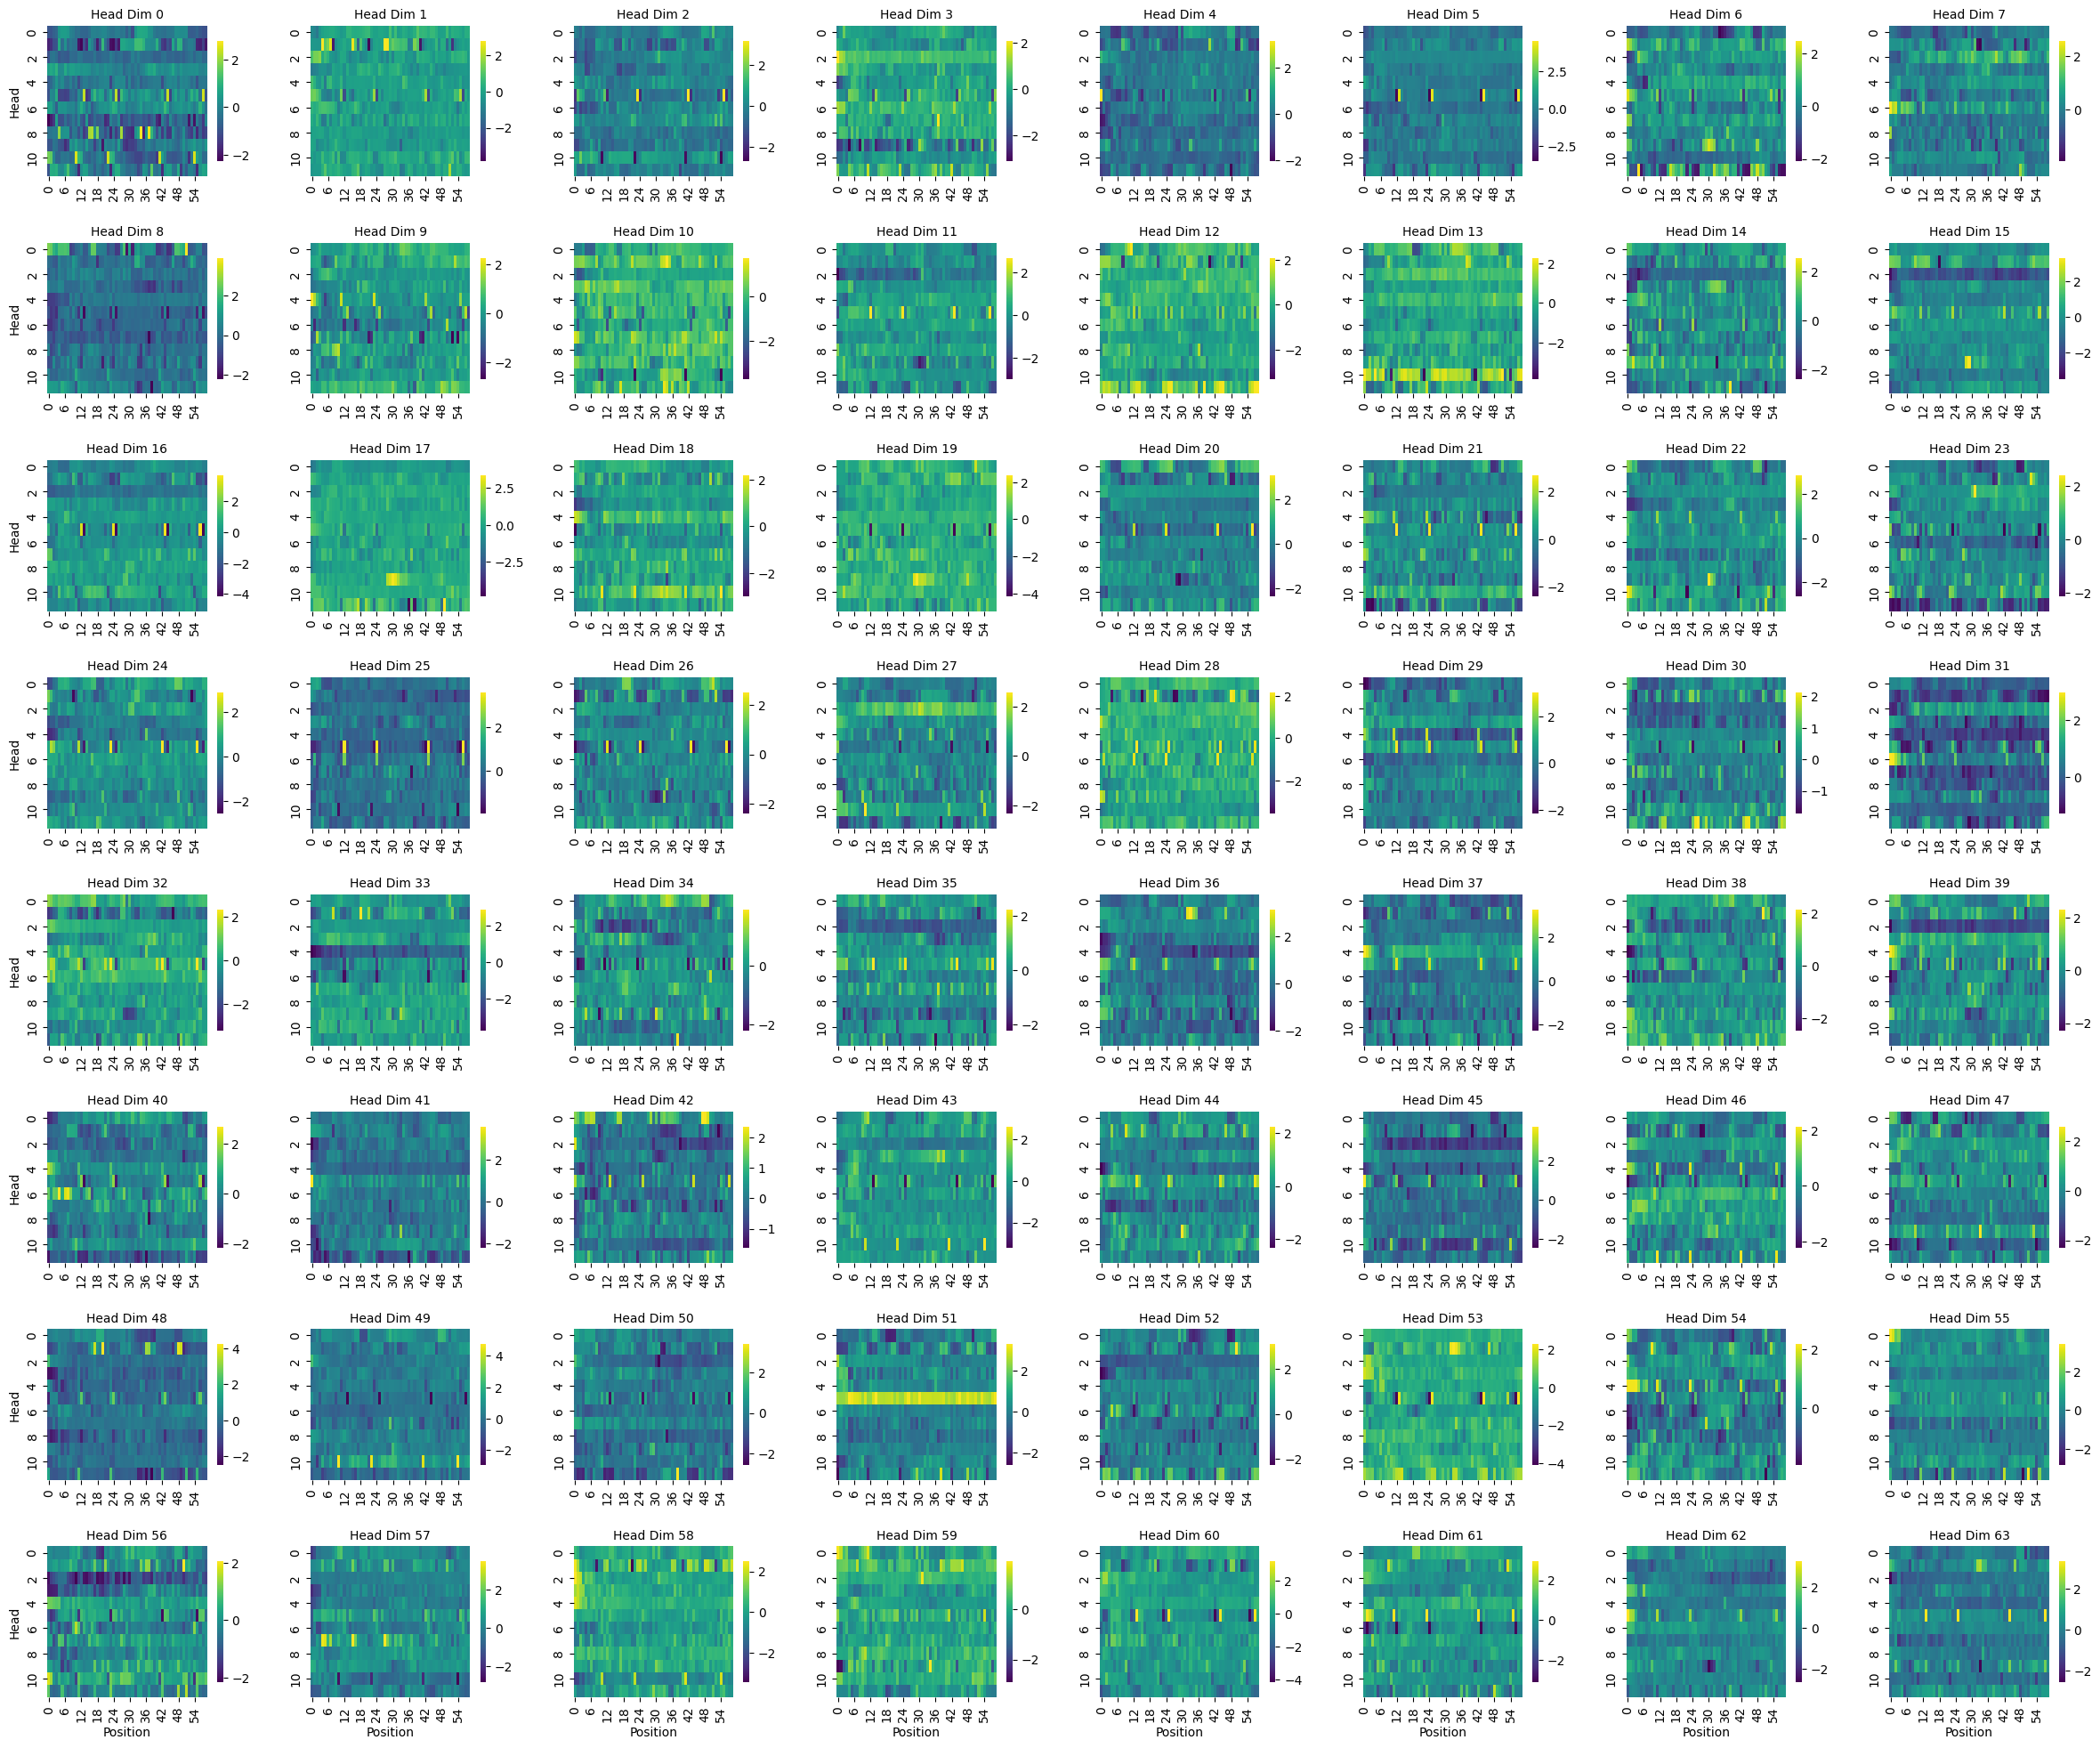

In [119]:
fig_all = visualize_attention_dimensions(cache['z'][1], n_heads, d_head)
plt.show()

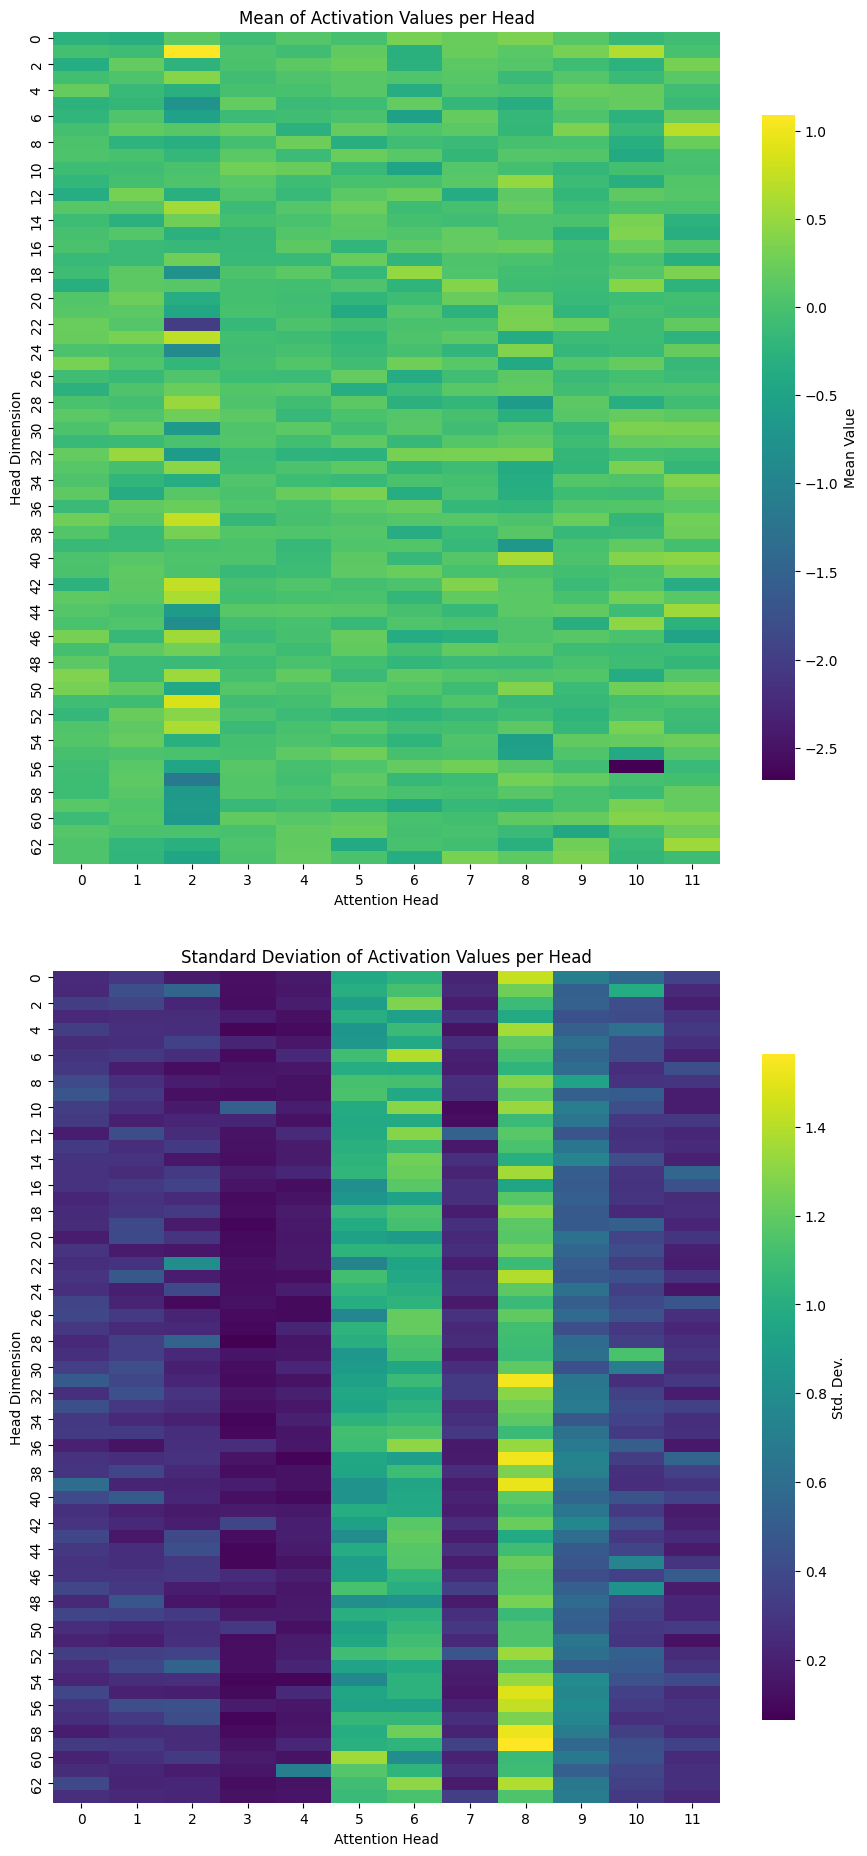

In [120]:
def visualize_head_statistics(z_output, n_heads, d_head):
    # Reshape to [batch_size, seq_len, n_heads, d_head]
    reshaped = z_output.cpu().numpy().reshape(z_output.shape[0], z_output.shape[1], n_heads, d_head)
    
    mean_values = np.mean(reshaped[0], axis=0)
    std_values = np.std(reshaped[0], axis=0)
    
    fig_width = max(8, n_heads * 0.8)
    fig_height_per_plot = max(4, d_head * 0.15)
    fig, axes = plt.subplots(2, 1, figsize=(fig_width, fig_height_per_plot * 2))
    
    sns.heatmap(
        mean_values.T, 
        ax=axes[0], 
        cmap='viridis', 
        cbar_kws={"shrink": 0.8, "label": "Mean Value"}
    )
    axes[0].set_title('Mean of Activation Values per Head')
    axes[0].set_xlabel('Attention Head')
    axes[0].set_ylabel('Head Dimension')
    
    # Plot Standard Deviation
    sns.heatmap(
        std_values.T, 
        ax=axes[1], 
        cmap='viridis', 
        cbar_kws={"shrink": 0.8, "label": "Std. Dev."}
    )
    axes[1].set_title('Standard Deviation of Activation Values per Head')
    axes[1].set_xlabel('Attention Head')
    axes[1].set_ylabel('Head Dimension')
    
    plt.tight_layout(pad=3.0) # Add padding to prevent title/label overlap
    return fig

fig = visualize_head_statistics(cache['z'][0], n_heads, d_head)
plt.show()

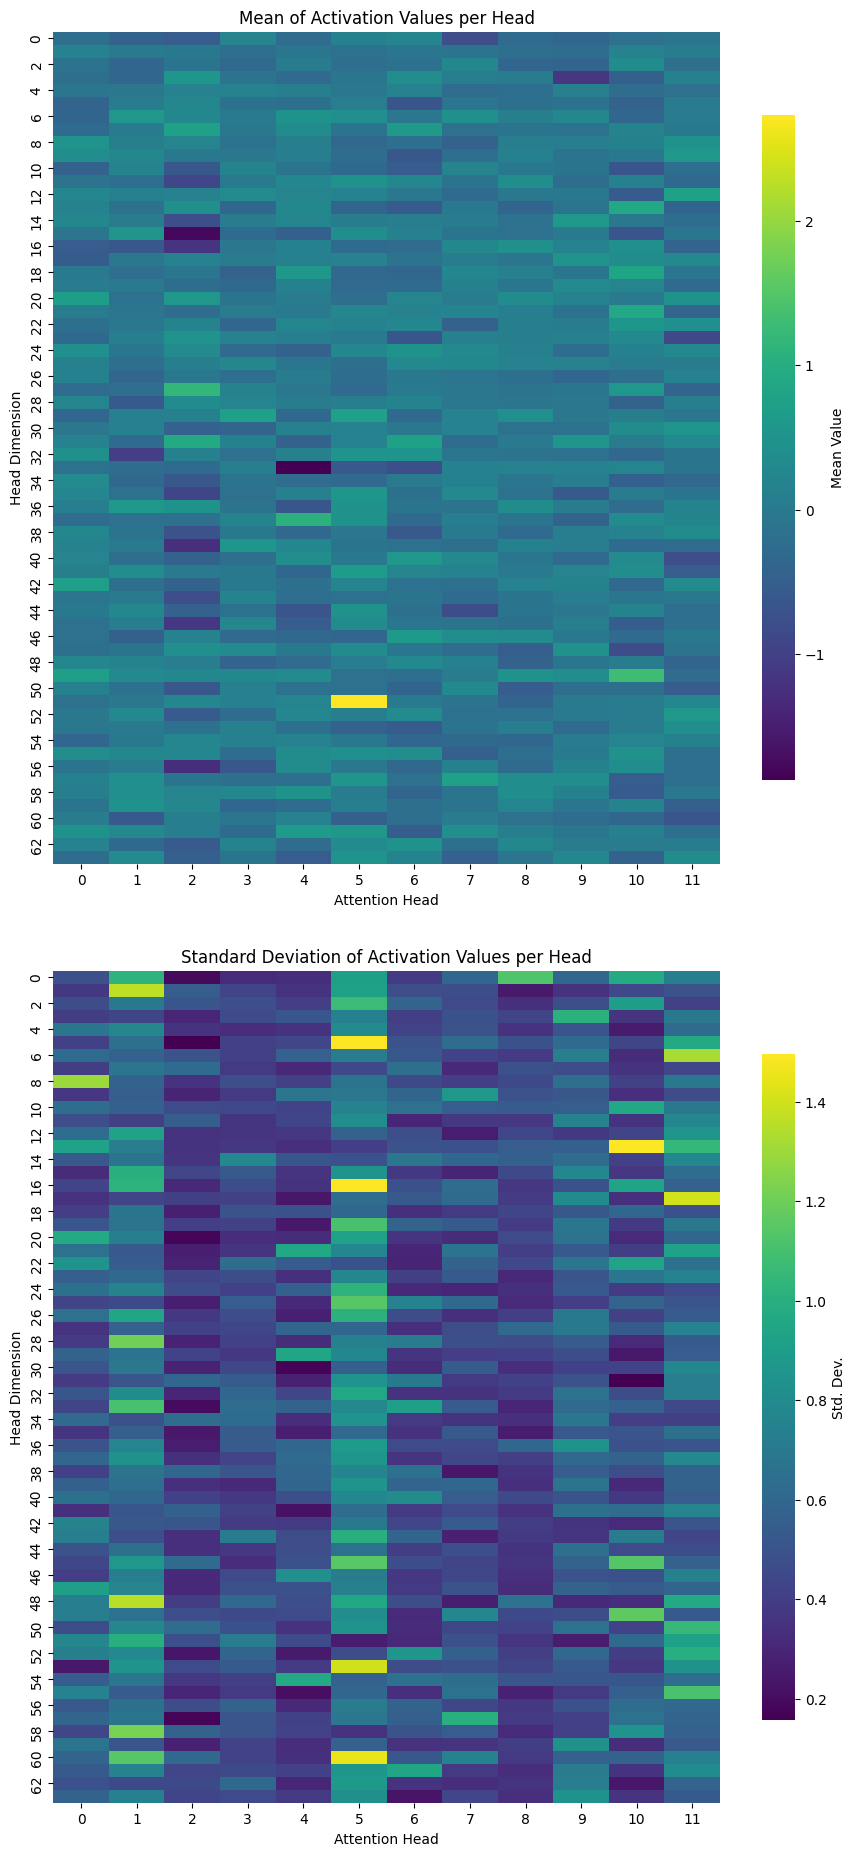

In [121]:
fig = visualize_head_statistics(cache['z'][1], n_heads, d_head)
plt.show()